# Genome Workup — 16S Identification & CheckM2 QC

Presentation figures and tables for the 16-sample bacterial genome set.

**Sections**
1. 16S BLAST results and annotation uncertainty
2. 16S clustering / mixed-assembly detection
3. CheckM2 completeness & contamination

All figures are rendered inline and also saved to `notebooks/figures/` as PNG (300 dpi) for slide use.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns

DATA = Path("../data")
FIGS = Path("figures")
FIGS.mkdir(exist_ok=True)

# Presentation-friendly defaults (Arial with fallbacks for non-Windows systems)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "mathtext.default": "regular",
})
import warnings
warnings.filterwarnings("ignore", message="findfont")
sns.set_palette("deep")

# Consistent colors
C_PASS = "#2a9d8f"
C_WARN = "#e9c46a"
C_FAIL = "#e76f51"
C_OTHER = "#bdbdbd"


In [2]:
# Load all result tables
blast_summary = pd.read_csv(DATA / "16S_analysis/summary.tsv", sep="\t")
blast_detail  = pd.read_csv(DATA / "16S_analysis/detail.tsv",  sep="\t")
qc_report     = pd.read_csv(DATA / "16S_clusters/metrics/qc_report.tsv", sep="\t")
checkm2       = pd.read_csv(DATA / "wgs_checkm2/summary.tsv", sep="\t")
all_blast     = pd.read_csv(DATA / "16S_results/all_results.tsv", sep="\t")

print(f"BLAST summary  : {len(blast_summary)} samples")
print(f"BLAST detail   : {len(blast_detail)} rows")
print(f"QC report      : {len(qc_report)} samples")
print(f"CheckM2 summary: {len(checkm2)} samples")
print(f"All BLAST hits : {len(all_blast):,} rows")


BLAST summary  : 16 samples
BLAST detail   : 1265 rows
QC report      : 17 samples
CheckM2 summary: 17 samples
All BLAST hits : 20,903 rows


## 1. 16S BLAST results and annotation uncertainty

Consensus 16S sequences (one per sample) were queried against NCBI via remote BLAST (megablast) with a
95% identity floor. Each sample yields many hits; the *distribution* of those hits over genera is what we
treat as annotation **uncertainty**:

- A sample whose hits are ≥99% one genus is a **confident** call.
- A sample whose hits are split across several genera indicates taxonomic ambiguity at the genus level,
  possible cross-genus conservation of the 16S locus, or (see Section 2) a mixed assembly.

Two uncertainty signals are shown here:
- **Top-genus fraction** (share of all ≥95% hits belonging to the top genus).
- **Number of distinct genera** detected at ≥95% identity.


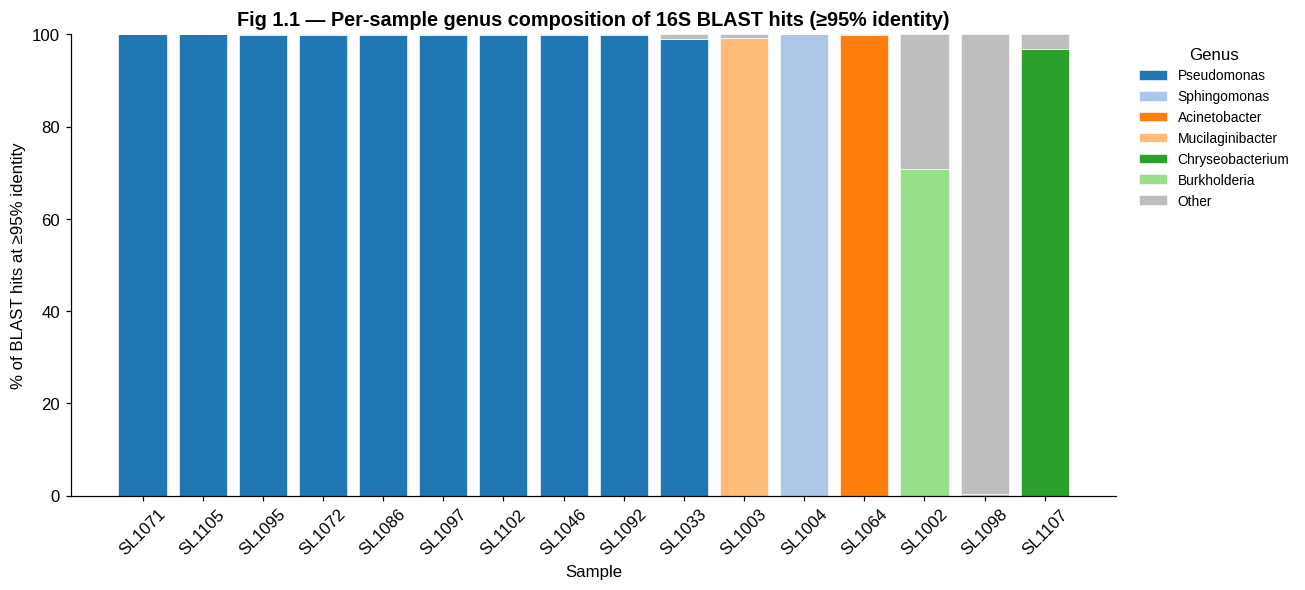

In [3]:
# Fig 1.1 — Per-sample genus distribution at >=95% identity (stacked bar, top-6 + Other)
genus_hits = (blast_detail
              .query("threshold_level == 'genus' and taxon_rank == 'genus'")
              .loc[:, ["sample", "taxon", "hit_count"]])

# Pivot: rows=sample, cols=genus, values=hit_count
pivot = genus_hits.pivot_table(index="sample", columns="taxon",
                               values="hit_count", aggfunc="sum", fill_value=0)

# Convert to % of row
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Keep top-6 genera globally; collapse remainder into "Other"
top_genera = (pivot_pct.sum(axis=0).sort_values(ascending=False).head(6).index.tolist())
pivot_plot = pivot_pct[top_genera].copy()
pivot_plot["Other"] = pivot_pct.drop(columns=top_genera).sum(axis=1)

# Sort samples so single-genus / high-confidence samples are visually grouped
pivot_plot = pivot_plot.loc[pivot_plot[top_genera[0]].sort_values(ascending=False).index]

palette = sns.color_palette("tab20", n_colors=len(top_genera)) + [C_OTHER]

fig, ax = plt.subplots(figsize=(12, 5.5))
bottoms = np.zeros(len(pivot_plot))
for col, color in zip(pivot_plot.columns, palette):
    ax.bar(pivot_plot.index, pivot_plot[col], bottom=bottoms,
           label=col, color=color, edgecolor="white", linewidth=0.4)
    bottoms += pivot_plot[col].values

ax.set_ylabel("% of BLAST hits at ≥95% identity")
ax.set_xlabel("Sample")
ax.set_title("Fig 1.1 — Per-sample genus composition of 16S BLAST hits (≥95% identity)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Genus", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fig1_1_genus_composition.png")
plt.show()


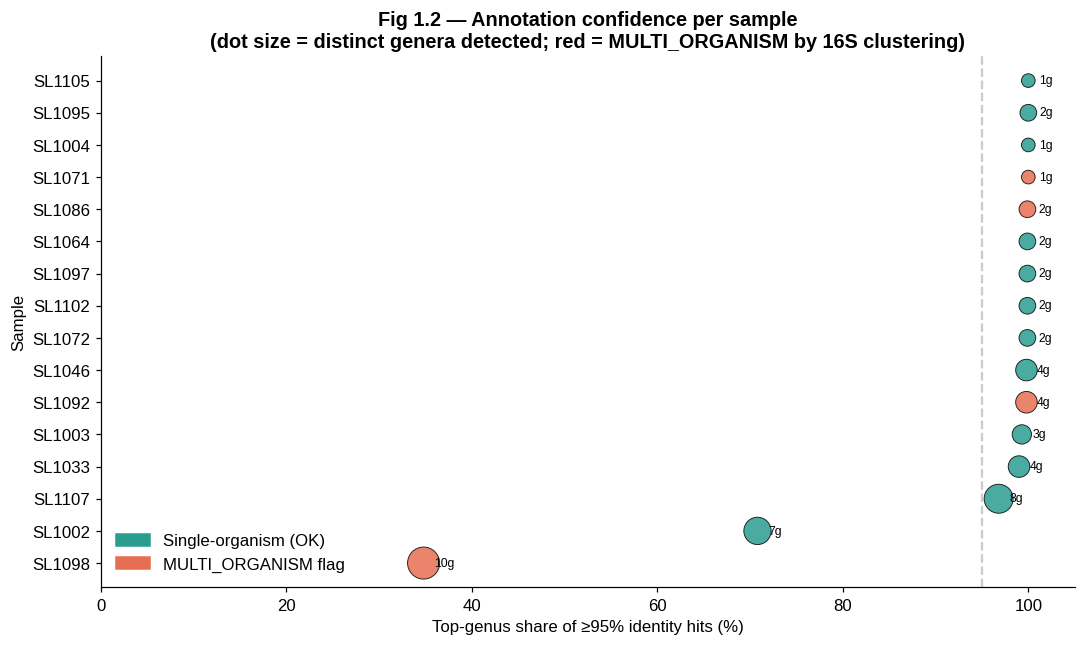

In [4]:
# Fig 1.2 — Top-genus confidence vs. number of distinct genera
df = blast_summary.copy()
df["n_genera"] = df["all_genera_ge95pct"].fillna("").apply(
    lambda s: 0 if s in ("", "N/A") else len([g for g in s.split(";") if g.strip()])
)
df["top_pct"] = pd.to_numeric(df["top_genus_pct_of_hits_ge95pct"], errors="coerce")

# Merge MULTI_ORGANISM flag from clustering
df = df.merge(qc_report[["sample", "status"]], on="sample", how="left")
df["is_mixed"] = df["status"] == "MULTI_ORGANISM"

df = df.sort_values("top_pct", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(df["is_mixed"], C_FAIL, C_PASS)
sizes = 40 + (df["n_genera"].fillna(0) * 40)

ax.scatter(df["top_pct"], df["sample"], s=sizes, c=colors, alpha=0.85,
           edgecolor="black", linewidth=0.6, zorder=3)

# Annotate N genera beside each dot
for _, r in df.iterrows():
    ax.annotate(f"{int(r['n_genera'])}g", (r["top_pct"], r["sample"]),
                xytext=(7, 0), textcoords="offset points", va="center", fontsize=8)

ax.axvline(95, ls="--", color="grey", alpha=0.4, label="95% confidence")
ax.set_xlim(0, 105)
ax.set_xlabel("Top-genus share of ≥95% identity hits (%)")
ax.set_ylabel("Sample")
ax.set_title("Fig 1.2 — Annotation confidence per sample\n(dot size = distinct genera detected; red = MULTI_ORGANISM by 16S clustering)")

# Legend
legend = [
    mpatches.Patch(color=C_PASS, label="Single-organism (OK)"),
    mpatches.Patch(color=C_FAIL, label="MULTI_ORGANISM flag"),
]
ax.legend(handles=legend, loc="lower left")
plt.tight_layout()
plt.savefig(FIGS / "fig1_2_confidence_dotplot.png")
plt.show()


In [5]:
# Table 1.1 — BLAST annotation summary (uncertainty-focused)
tab1 = blast_summary[[
    "sample", "n_total_hits", "top_genus_ge95pct",
    "top_genus_pct_of_hits_ge95pct", "all_genera_ge95pct",
    "top_species_ge97pct", "top_species_pct_of_hits_ge97pct",
    "n_failed_names",
]].copy()
tab1.columns = [
    "sample", "n_hits_≥95%", "top_genus",
    "top_genus_%", "all_genera_seen_≥95%",
    "top_species_≥97%", "top_species_%",
    "n_unmapped_names",
]
tab1.to_csv(FIGS / "table1_1_blast_summary.csv", index=False)
tab1.style.set_caption("Table 1.1 — Per-sample 16S BLAST annotation & uncertainty signals")


,sample,n_hits_≥95%,top_genus,top_genus_%,all_genera_seen_≥95%,top_species_≥97%,top_species_%,n_unmapped_names
0,SL1002,895,Burkholderia,70.800000,Burkholderia; Caballeronia; Paraburkholderia; Eubacterium; Pararobbsia; Trinickia; Beta,Burkholderia glumae,36.400000,40
1,SL1003,457,Mucilaginibacter,99.300000,Mucilaginibacter; Sphingobacterium; Pedobacter,Mucilaginibacter saanensis,8.300000,172
2,SL1004,517,Sphingomonas,100.000000,Sphingomonas,Sphingomonas aerolata,11.000000,272
3,SL1033,1654,Pseudomonas,99.000000,Pseudomonas; Stutzerimonas; Xylella; Eubacterium,Pseudomonas fluorescens,4.800000,23
4,SL1046,1971,Pseudomonas,99.800000,Pseudomonas; Bacillus; Impatiens; Klebsiella,Pseudomonas poae,8.200000,41
5,SL1064,1486,Acinetobacter,99.900000,Acinetobacter; Lysinibacillus,Acinetobacter pittii,37.800000,70
6,SL1071,2,Pseudomonas,100.000000,Pseudomonas,nan,nan,1
7,SL1072,1471,Pseudomonas,99.900000,Pseudomonas; Bacillus,Pseudomonas poae,11.300000,75
8,SL1086,1425,Pseudomonas,99.900000,Pseudomonas; Bacillus,Pseudomonas poae,11.900000,92
9,SL1092,1934,Pseudomonas,99.800000,Pseudomonas; Impatiens; Bacillus; Klebsiella,Pseudomonas veronii,7.200000,51


## 2. 16S clustering — detecting mixed assemblies

Each genome carries multiple 16S gene copies. If all copies are highly similar, the assembly is a single
organism. If they split into two or more well-separated groups, the assembly is **mixed** (contamination,
co-culture, or chimeric bin).

**Method.** Per sample, all 16S copies are aligned with MUSCLE. Alignment-based pairwise identities are
computed (robust to small indels). Copies are single-linkage clustered at 90% identity. Samples with more
than one cluster are flagged as `MULTI_ORGANISM`.


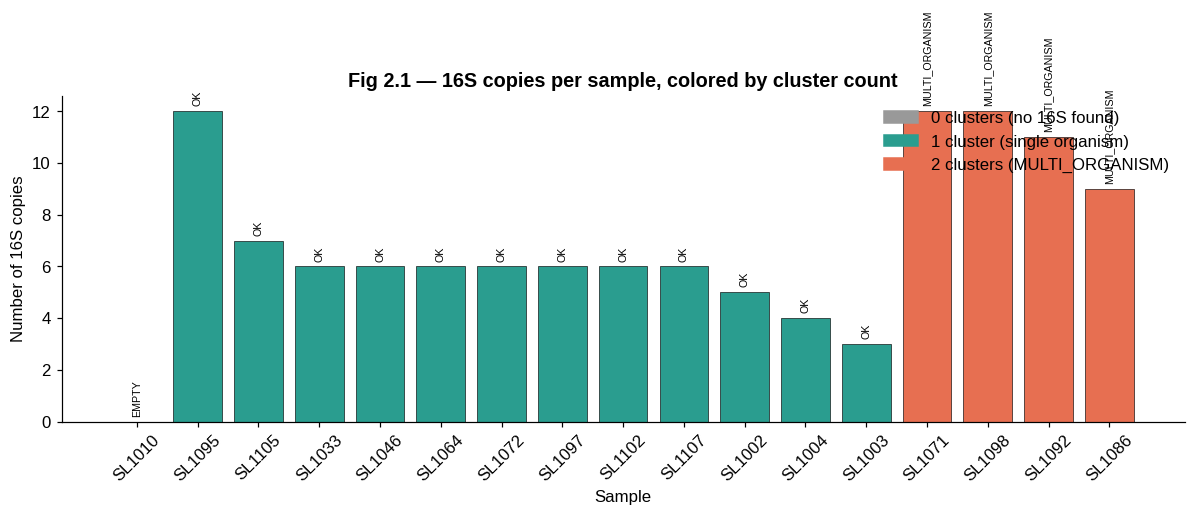

In [6]:
# Fig 2.1 — 16S copy count per sample, colored by cluster count
qc = qc_report.copy()
qc["n_clusters_int"] = pd.to_numeric(qc["n_clusters"], errors="coerce").fillna(0).astype(int)

cluster_color = {0: "#999999", 1: C_PASS, 2: C_FAIL, 3: "#6a0572"}
qc["color"] = qc["n_clusters_int"].map(lambda c: cluster_color.get(c, "#6a0572"))
qc = qc.sort_values(["n_clusters_int", "n_copies"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(qc["sample"], qc["n_copies"], color=qc["color"],
       edgecolor="black", linewidth=0.4)

for _, r in qc.iterrows():
    ax.text(r["sample"], r["n_copies"] + 0.2, r["status"],
            ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_ylabel("Number of 16S copies")
ax.set_xlabel("Sample")
ax.set_title("Fig 2.1 — 16S copies per sample, colored by cluster count")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

handles = [
    mpatches.Patch(color="#999999", label="0 clusters (no 16S found)"),
    mpatches.Patch(color=C_PASS,    label="1 cluster (single organism)"),
    mpatches.Patch(color=C_FAIL,    label="2 clusters (MULTI_ORGANISM)"),
]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.savefig(FIGS / "fig2_1_copy_counts.png")
plt.show()


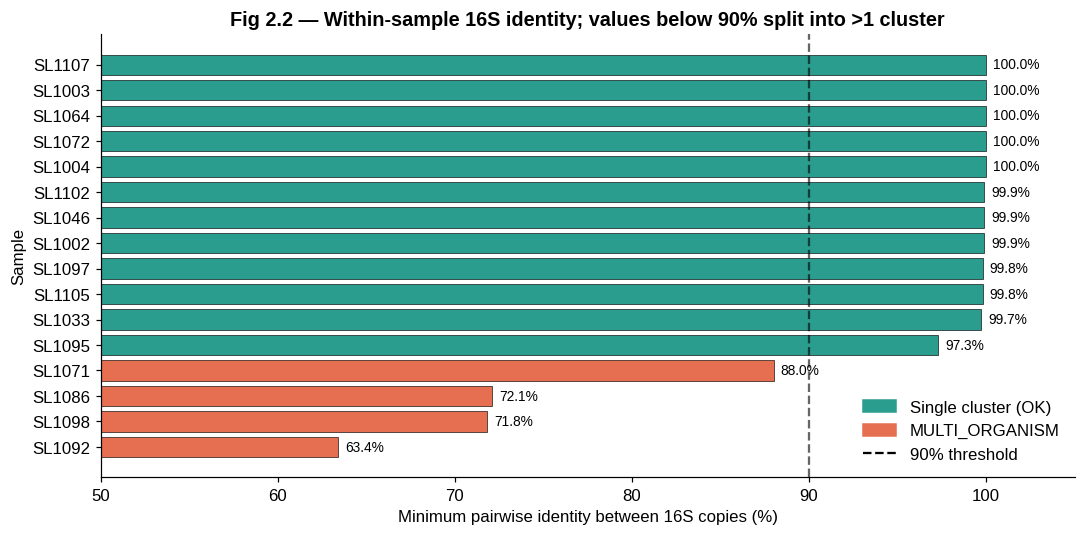

In [7]:
# Fig 2.2 — Minimum pairwise identity per sample (the clustering signal)
qc2 = qc_report.copy()
qc2["min_id"] = pd.to_numeric(qc2["min_pairwise_identity"], errors="coerce")
qc2 = qc2.dropna(subset=["min_id"]).sort_values("min_id")

colors = np.where(qc2["status"] == "MULTI_ORGANISM", C_FAIL, C_PASS)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(qc2["sample"], qc2["min_id"], color=colors, edgecolor="black", linewidth=0.4)

ax.axvline(90, ls="--", color="black", alpha=0.6, label="90% clustering threshold")
for bar, val in zip(bars, qc2["min_id"]):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlim(50, 105)
ax.set_xlabel("Minimum pairwise identity between 16S copies (%)")
ax.set_ylabel("Sample")
ax.set_title("Fig 2.2 — Within-sample 16S identity; values below 90% split into >1 cluster")
handles = [
    mpatches.Patch(color=C_PASS, label="Single cluster (OK)"),
    mpatches.Patch(color=C_FAIL, label="MULTI_ORGANISM"),
]
ax.legend(handles=handles + [plt.Line2D([0],[0], ls="--", color="black", label="90% threshold")],
          loc="lower right")
plt.tight_layout()
plt.savefig(FIGS / "fig2_2_min_pairwise_identity.png")
plt.show()


In [8]:
# Table 2.1 — Per-sample 16S QC report
tab2 = qc_report[["sample", "n_copies", "length_range",
                  "min_pairwise_identity", "n_clusters", "status"]].copy()
tab2.columns = ["sample", "n_copies", "length_range",
                "min_pairwise_id_%", "n_clusters", "status"]
tab2.to_csv(FIGS / "table2_1_qc_report.csv", index=False)
tab2.style.set_caption("Table 2.1 — 16S copy QC and clustering")


,sample,n_copies,length_range,min_pairwise_id_%,n_clusters,status
0,SL1002,5,1519-1519,99.900000,1,OK
1,SL1003,3,1510-1510,100.000000,1,OK
2,SL1004,4,1479-1479,100.000000,1,OK
3,SL1010,0,nan,nan,0,EMPTY
4,SL1033,6,1525-1525,99.700000,1,OK
5,SL1046,6,1525-1525,99.900000,1,OK
6,SL1064,6,1526-1526,100.000000,1,OK
7,SL1071,12,1525-1526,88.000000,2,MULTI_ORGANISM
8,SL1072,6,1525-1525,100.000000,1,OK
9,SL1086,9,1505-1525,72.100000,2,MULTI_ORGANISM


## 3. CheckM2 — completeness and contamination

**What CheckM2 does.** CheckM2 (Chklovski *et al.* 2023) estimates two genome-quality metrics using
machine-learning models trained on ~1.5 M high-quality reference genomes:

- **Completeness** — fraction of a canonical single-copy-gene set expected to be present.
- **Contamination** — estimated extra sequence from foreign genomes, based on duplicated / out-of-place markers.

CheckM2 uses one of two predictors per sample:
- **Neural Network (Specific Model)** — used when the genome resembles taxa in the reference set.
- **Gradient Boost (General Model)** — fallback for novel taxa.

**QC thresholds used here.** `PASS = completeness ≥ 90% AND contamination < 5%`, otherwise `FAIL`.
Contamination > 100% indicates the bin contains more than one full genome's worth of duplicated markers —
a strong signal that the assembly is a mixture.


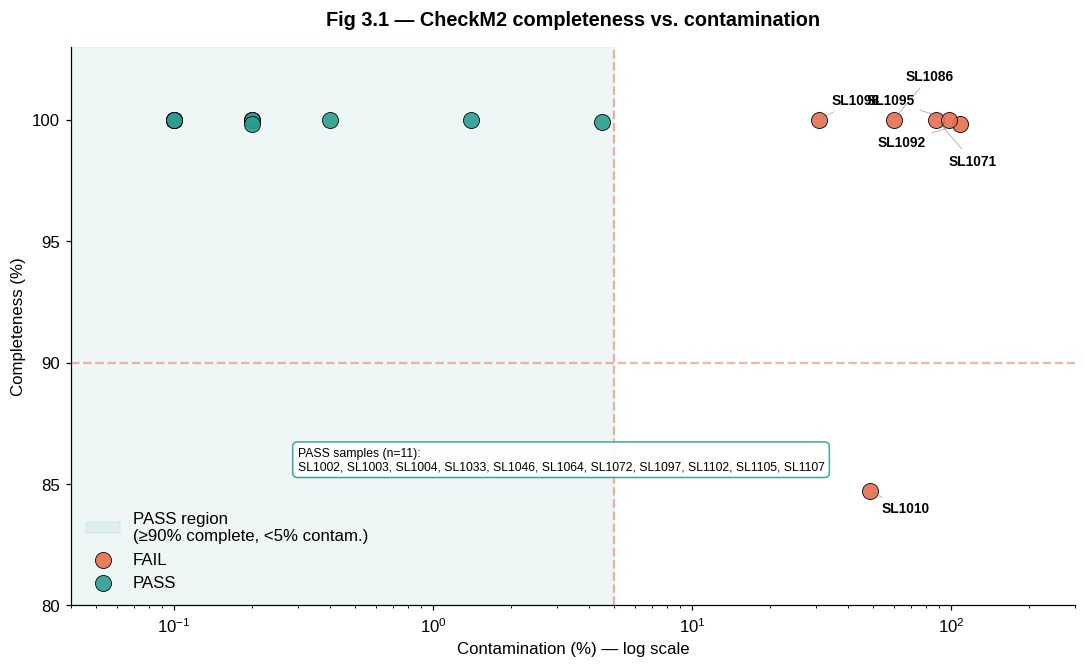

In [9]:
# Fig 3.1 — Completeness vs contamination (log-x for contamination)
cm = checkm2.copy()
cm["contamination_plot"] = cm["contamination"].replace(0, 0.05)  # log-scale floor

fig, ax = plt.subplots(figsize=(10, 6.2))

# Shade PASS region (contam < 5, completeness >= 90)
ax.axvspan(0.04, 5, color=C_PASS, alpha=0.08, label="PASS region\n(≥90% complete, <5% contam.)")
ax.axvline(5, ls="--", color=C_FAIL, alpha=0.5)
ax.axhline(90, ls="--", color=C_FAIL, alpha=0.5)

color_map = {"PASS": C_PASS, "WARN": C_WARN, "FAIL": C_FAIL}
for flag, sub in cm.groupby("qc_flag"):
    ax.scatter(sub["contamination_plot"], sub["completeness"],
               s=110, c=color_map.get(flag, "#555"), edgecolor="black",
               linewidth=0.6, alpha=0.9, label=flag, zorder=3)

# Label only FAIL samples individually; summarize PASS samples in a text box.
# FAIL samples are more spread out and each one tells its own story.
fail = cm[cm["qc_flag"] == "FAIL"].copy().sort_values("contamination")
passed = cm[cm["qc_flag"] == "PASS"].copy().sort_values("sample")

# Stagger FAIL labels by alternating offsets
FAIL_OFFSETS = [(8, 10), (8, -14), (8, 26), (8, -30), (-54, 10), (-54, -14)]
for i, (_, r) in enumerate(fail.iterrows()):
    dx, dy = FAIL_OFFSETS[i % len(FAIL_OFFSETS)]
    ax.annotate(r["sample"],
                (r["contamination_plot"], r["completeness"]),
                xytext=(dx, dy), textcoords="offset points",
                fontsize=9, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5, alpha=0.7))

# PASS summary box in empty middle area
pass_names = ", ".join(passed["sample"].tolist())
pass_label = "PASS samples (n={}):\n{}".format(len(passed), pass_names)
ax.text(0.3, 86, pass_label,
        fontsize=8, va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor=C_PASS, linewidth=1.0, alpha=0.9))

ax.set_xscale("log")
ax.set_xlim(0.04, 300)
ax.set_ylim(80, 103)
ax.set_xlabel("Contamination (%) — log scale")
ax.set_ylabel("Completeness (%)")
ax.set_title("Fig 3.1 — CheckM2 completeness vs. contamination", pad=14)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIGS / "fig3_1_checkm2_scatter.png")
plt.show()


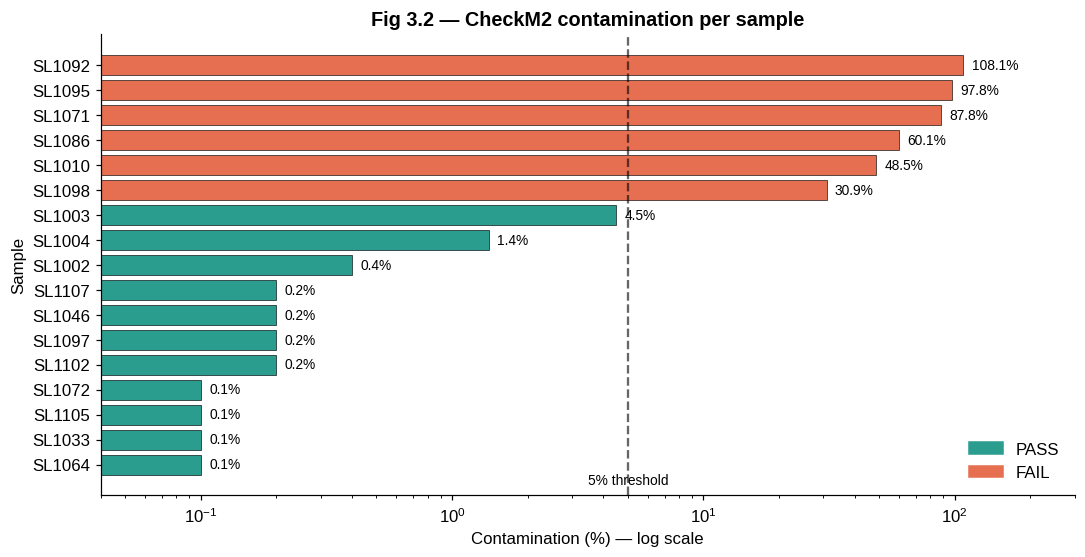

In [10]:
# Fig 3.2 — Per-sample contamination bar (log scale; 5% threshold line)
cm2 = checkm2.sort_values("contamination").copy()
cm2["contam_plot"] = cm2["contamination"].replace(0, 0.05)
colors = cm2["qc_flag"].map({"PASS": C_PASS, "WARN": C_WARN, "FAIL": C_FAIL}).fillna("#888")

fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.barh(cm2["sample"], cm2["contam_plot"], color=colors,
               edgecolor="black", linewidth=0.4)
ax.axvline(5, ls="--", color="black", alpha=0.6)
ax.text(5, -0.8, "5% threshold", color="black", fontsize=9, ha="center")

for bar, val in zip(bars, cm2["contamination"]):
    ax.text(max(val, 0.05) * 1.08, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xscale("log")
ax.set_xlim(0.04, 300)
ax.set_xlabel("Contamination (%) — log scale")
ax.set_ylabel("Sample")
ax.set_title("Fig 3.2 — CheckM2 contamination per sample")
handles = [mpatches.Patch(color=C_PASS, label="PASS"),
           mpatches.Patch(color=C_FAIL, label="FAIL")]
ax.legend(handles=handles, loc="lower right")
plt.tight_layout()
plt.savefig(FIGS / "fig3_2_contamination_bar.png")
plt.show()


In [11]:
# Table 3.1 — CheckM2 per-sample results
tab3 = checkm2[[
    "sample", "completeness", "contamination", "completeness_model",
    "genome_size", "gc_content", "contig_n50", "qc_flag",
]].copy()
tab3.columns = [
    "sample", "completeness_%", "contamination_%", "model",
    "genome_size_bp", "gc", "contig_N50_bp", "flag",
]
tab3.to_csv(FIGS / "table3_1_checkm2.csv", index=False)
tab3.style.set_caption("Table 3.1 — CheckM2 completeness, contamination, and QC flags").format({
    "completeness_%": "{:.1f}",
    "contamination_%": "{:.1f}",
    "gc": "{:.2f}",
    "genome_size_bp": "{:,.0f}",
    "contig_N50_bp": "{:,.0f}",
})


,sample,completeness_%,contamination_%,model,genome_size_bp,gc,contig_N50_bp,flag
0,SL1002,100.0,0.4,Neural Network (Specific Model),"6,925,371",0.62,"1,302,054",PASS
1,SL1003,99.9,4.5,Neural Network (Specific Model),"7,094,092",0.42,"7,094,092",PASS
2,SL1004,100.0,1.4,Neural Network (Specific Model),"4,831,925",0.65,"4,473,502",PASS
3,SL1010,84.7,48.5,Gradient Boost (General Model),"36,969,037",0.51,"338,873",FAIL
4,SL1033,100.0,0.1,Neural Network (Specific Model),"6,359,510",0.59,"6,359,510",PASS
5,SL1046,100.0,0.2,Neural Network (Specific Model),"6,931,287",0.60,"6,880,132",PASS
6,SL1064,100.0,0.1,Neural Network (Specific Model),"4,194,864",0.39,"4,127,218",PASS
7,SL1071,100.0,87.8,Neural Network (Specific Model),"9,191,372",0.52,"4,996,611",FAIL
8,SL1072,100.0,0.1,Neural Network (Specific Model),"6,477,378",0.60,"6,329,413",PASS
9,SL1086,100.0,60.1,Neural Network (Specific Model),"11,055,985",0.50,"6,500,924",FAIL


## 4. GTDB-tk whole-genome taxonomy

**What GTDB-tk does.** GTDB-tk places each genome in the Genome Taxonomy Database reference tree using
~120 single-copy marker proteins (Bacteria) / 53 markers (Archaea), then refines the call via FastANI
against the nearest reference genomes. Unlike 16S, it uses the entire genome's marker set, so it:

- Is more robust to partial or contaminated assemblies at the genus level
- Can assign species when FastANI ≥ 95% against a reference (`ani_screen` method)
- Falls back to tree placement + RED (Relative Evolutionary Divergence) when no close reference exists

**Classification methods seen in the output**
- `ani_screen` — species-level call, high confidence
- `taxonomic classification defined by topology and ANI` — genus-level placement in tree
- `taxonomic novelty determined using RED` — divergent; only high-level taxonomy given

**⚠ Note on contaminated samples.** CheckM2 flagged 6 samples as FAIL (contamination 30–108%). Their GTDB-tk
calls are shown with a red outline below — these bins likely contain ≥2 organisms, so a single-label
classification is inherently incomplete. SL1010 (48% contamination, 85% complete) is classified as *Archaea*,
almost certainly an artifact of the chimeric bin.


In [12]:
# Load GTDB-tk summary and build a merged view with 16S and CheckM2
gtdb = pd.read_csv(DATA / "wgs_gtdbtk/summary.tsv", sep="\t")

# Normalize GTDB-style Pseudomonas_A..._E back to Pseudomonas for genus comparison
def norm_genus(g):
    if not isinstance(g, str) or not g:
        return g
    # GTDB splits (e.g., Pseudomonas_E) use a trailing "_<letter>"
    parts = g.rsplit("_", 1)
    if len(parts) == 2 and len(parts[1]) == 1 and parts[1].isalpha():
        return parts[0]
    return g

gtdb["genus_norm"] = gtdb["genus"].apply(norm_genus)

# Merge with 16S top genus and CheckM2 flag
cmp = gtdb.merge(
    blast_summary[["sample", "top_genus_ge95pct", "top_genus_pct_of_hits_ge95pct",
                   "top_species_ge97pct", "all_genera_ge95pct"]],
    on="sample", how="left",
).merge(
    checkm2[["sample", "completeness", "contamination", "qc_flag"]],
    on="sample", how="left",
).merge(
    qc_report[["sample", "status"]].rename(columns={"status": "qc_16s_status"}),
    on="sample", how="left",
)
cmp["contaminated"] = cmp["qc_flag"] == "FAIL"

# Agreement logic for later
def agreement(row):
    if row["domain"] == "Archaea":
        return "ARCHAEA/NOVELTY"
    s16 = row.get("top_genus_ge95pct")
    if pd.isna(s16) or s16 in ("", "N/A"):
        return "NO_16S"
    gtdb_g = row["genus_norm"]
    # Species match (if GTDB has a species)
    gtdb_sp = row.get("species")
    if isinstance(gtdb_sp, str) and gtdb_sp.strip():
        # strip _A..._E suffix in species too
        gtdb_sp_norm = " ".join(norm_genus(p) for p in gtdb_sp.split())
        s16_species = row.get("top_species_ge97pct")
        if isinstance(s16_species, str) and s16_species == gtdb_sp_norm:
            return "SPECIES_MATCH"
    # Genus match
    if isinstance(gtdb_g, str) and s16 == gtdb_g:
        return "GENUS_MATCH"
    # Genus in all_genera list (weaker agreement)
    allg = row.get("all_genera_ge95pct") or ""
    if isinstance(allg, str) and gtdb_g in [g.strip() for g in allg.split(";")]:
        return "GENUS_IN_16S_SET"
    return "DISAGREE"

cmp["agreement"] = cmp.apply(agreement, axis=1)
print(cmp[["sample", "genus_norm", "species", "top_genus_ge95pct", "top_species_ge97pct",
           "contaminated", "agreement"]].to_string(index=False))


sample       genus_norm                        species top_genus_ge95pct            top_species_ge97pct  contaminated        agreement
SL1002     Caballeronia                            NaN      Burkholderia            Burkholderia glumae         False GENUS_IN_16S_SET
SL1003 Mucilaginibacter                            NaN  Mucilaginibacter     Mucilaginibacter saanensis         False      GENUS_MATCH
SL1004     Sphingomonas                            NaN      Sphingomonas          Sphingomonas aerolata         False      GENUS_MATCH
SL1010              NaN                            NaN               NaN                            NaN          True  ARCHAEA/NOVELTY
SL1033      Pseudomonas   Pseudomonas_E helmanticensis       Pseudomonas        Pseudomonas fluorescens         False      GENUS_MATCH
SL1046      Pseudomonas         Pseudomonas_E edaphica       Pseudomonas               Pseudomonas poae         False      GENUS_MATCH
SL1064    Acinetobacter      Acinetobacter sp003410005 

/tmp/ipykernel_1360384/1407834881.py:58: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1360384/1407834881.py:59: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(FIGS / "fig4_1_gtdbtk_calls.png")


/home/user/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


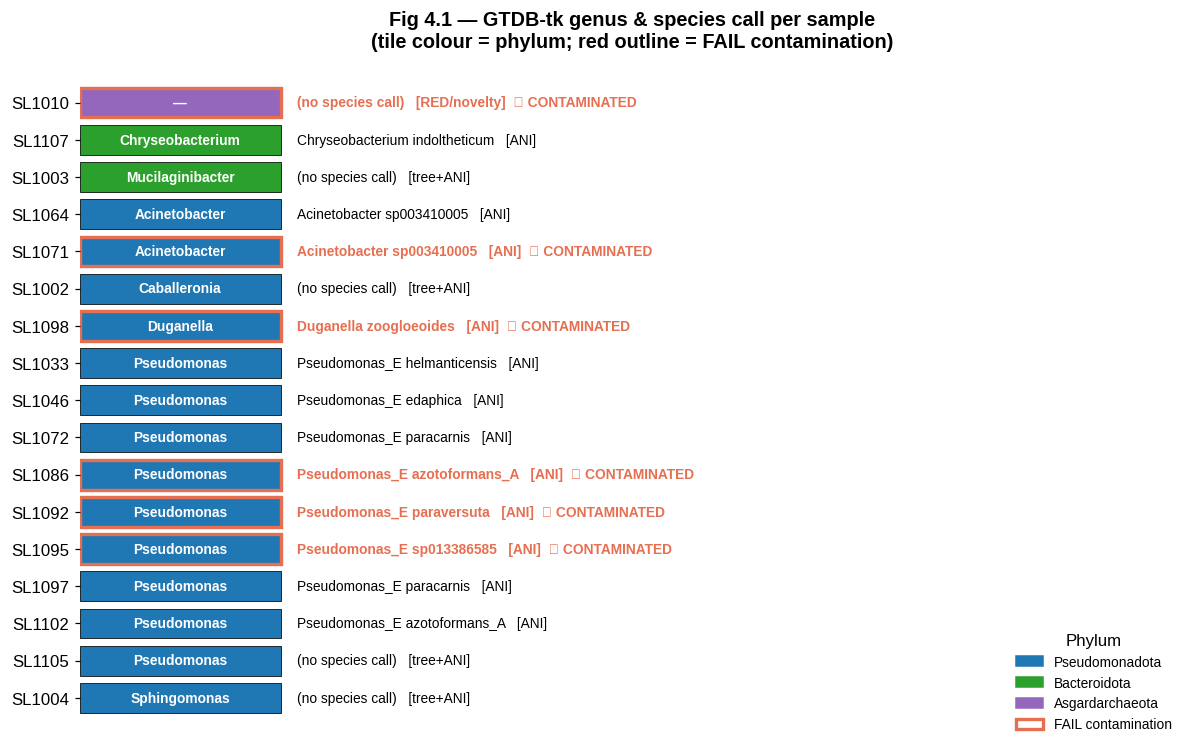

In [13]:
# Fig 4.1 — GTDB-tk per-sample call panel (genus + species), contaminated outlined red
# Layout: one row per sample, single colored tile = genus, species text to the right.
phy_colors = {
    "Pseudomonadota": "#1f77b4",
    "Bacteroidota":   "#2ca02c",
    "Asgardarchaeota": "#9467bd",
}
# Parse phylum from classification string
def phylum_of(cls):
    if not isinstance(cls, str):
        return ""
    for tok in cls.split(";"):
        tok = tok.strip()
        if tok.startswith("p__"):
            return tok[3:]
    return ""
cmp["phylum"] = cmp["classification"].apply(phylum_of)

ordered = cmp.sort_values(["phylum", "genus_norm", "sample"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(ordered))
# Genus tile
for i, r in ordered.iterrows():
    color = phy_colors.get(r["phylum"], "#888888")
    # Outline red if contaminated
    edgecolor = C_FAIL if r["contaminated"] else "black"
    linewidth = 2.2 if r["contaminated"] else 0.5
    ax.barh(i, 1, left=0, color=color, edgecolor=edgecolor, linewidth=linewidth)
    # Genus label on tile
    ax.text(0.5, i, r["genus_norm"] if isinstance(r["genus_norm"], str) and r["genus_norm"] else "—",
            ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    # Species + method to the right
    sp = r["species"] if isinstance(r["species"], str) and r["species"].strip() else "(no species call)"
    method_tag = {"ani_screen": "ANI",
                  "taxonomic classification defined by topology and ANI": "tree+ANI",
                  "taxonomic novelty determined using RED": "RED/novelty"}.get(r["classification_method"], r["classification_method"][:12])
    flag = "  ⚠ CONTAMINATED" if r["contaminated"] else ""
    ax.text(1.08, i, f"{sp}   [{method_tag}]{flag}", va="center", fontsize=9,
            color=(C_FAIL if r["contaminated"] else "black"),
            fontweight=("bold" if r["contaminated"] else "normal"))

ax.set_yticks(y)
ax.set_yticklabels(ordered["sample"])
ax.set_xlim(0, 5.5)
ax.set_xticks([])
ax.set_xlabel("")
ax.set_title("Fig 4.1 — GTDB-tk genus & species call per sample\n(tile colour = phylum; red outline = FAIL contamination)")
ax.invert_yaxis()
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Phylum legend
handles = [mpatches.Patch(color=c, label=p) for p, c in phy_colors.items()]
handles.append(mpatches.Patch(facecolor="white", edgecolor=C_FAIL, linewidth=2.2,
                              label="FAIL contamination"))
ax.legend(handles=handles, loc="lower right", fontsize=9, title="Phylum")
plt.tight_layout()
plt.savefig(FIGS / "fig4_1_gtdbtk_calls.png")
plt.show()


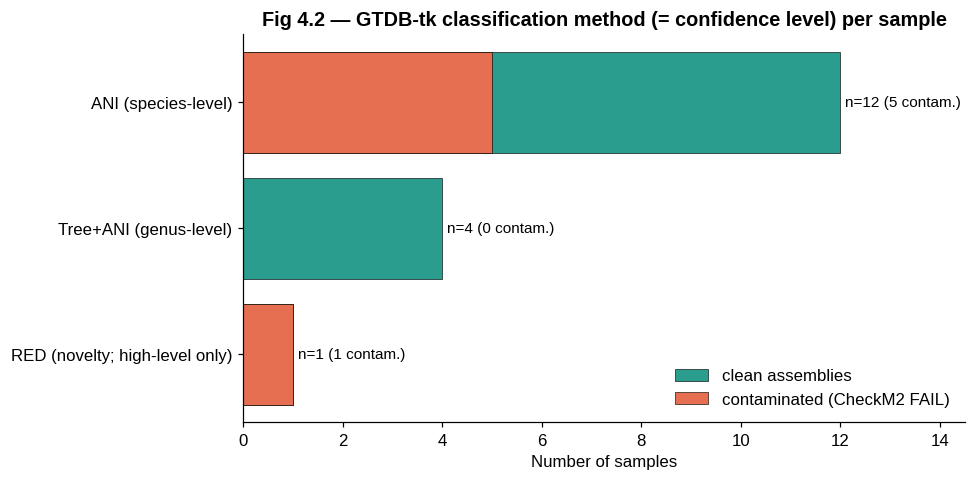

In [14]:
# Fig 4.2 — Classification-method breakdown: how confident is each GTDB call?
method_map = {
    "ani_screen": "ANI (species-level)",
    "taxonomic classification defined by topology and ANI": "Tree+ANI (genus-level)",
    "taxonomic novelty determined using RED": "RED (novelty; high-level only)",
}
cmp["method_label"] = cmp["classification_method"].map(method_map).fillna(cmp["classification_method"])
counts = cmp["method_label"].value_counts()
contam_counts = cmp[cmp["contaminated"]]["method_label"].value_counts().reindex(counts.index, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(counts))
ax.barh(y, counts.values, color=C_PASS, edgecolor="black", linewidth=0.4, label="clean assemblies")
ax.barh(y, contam_counts.values, color=C_FAIL, edgecolor="black", linewidth=0.4, label="contaminated (CheckM2 FAIL)")
for i, (n, cc) in enumerate(zip(counts.values, contam_counts.values)):
    ax.text(n + 0.1, i, f"n={n} ({cc} contam.)", va="center", fontsize=10)
ax.set_yticks(y)
ax.set_yticklabels(counts.index)
ax.set_xlabel("Number of samples")
ax.set_title("Fig 4.2 — GTDB-tk classification method (= confidence level) per sample")
ax.invert_yaxis()
ax.set_xlim(0, counts.max() + 2.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGS / "fig4_2_gtdbtk_methods.png")
plt.show()


In [15]:
# Table 4.1 — GTDB-tk results per sample
tab4 = cmp[["sample", "domain", "genus", "genus_norm", "species",
            "classification_method", "contaminated"]].copy()
tab4.columns = ["sample", "domain", "GTDB_genus", "genus_normalized",
                "GTDB_species", "classification_method", "contaminated_per_CheckM2"]
tab4.to_csv(FIGS / "table4_1_gtdbtk.csv", index=False)
tab4.style.set_caption("Table 4.1 — GTDB-tk classification per sample")


,sample,domain,GTDB_genus,genus_normalized,GTDB_species,classification_method,contaminated_per_CheckM2
0,SL1002,Bacteria,Caballeronia,Caballeronia,nan,taxonomic classification defined by topology and ANI,False
1,SL1003,Bacteria,Mucilaginibacter,Mucilaginibacter,nan,taxonomic classification defined by topology and ANI,False
2,SL1004,Bacteria,Sphingomonas,Sphingomonas,nan,taxonomic classification defined by topology and ANI,False
3,SL1010,Archaea,nan,nan,nan,taxonomic novelty determined using RED,True
4,SL1033,Bacteria,Pseudomonas_E,Pseudomonas,Pseudomonas_E helmanticensis,ani_screen,False
5,SL1046,Bacteria,Pseudomonas_E,Pseudomonas,Pseudomonas_E edaphica,ani_screen,False
6,SL1064,Bacteria,Acinetobacter,Acinetobacter,Acinetobacter sp003410005,ani_screen,False
7,SL1071,Bacteria,Acinetobacter,Acinetobacter,Acinetobacter sp003410005,ani_screen,True
8,SL1072,Bacteria,Pseudomonas_E,Pseudomonas,Pseudomonas_E paracarnis,ani_screen,False
9,SL1086,Bacteria,Pseudomonas_E,Pseudomonas,Pseudomonas_E azotoformans_A,ani_screen,True


## 5. 16S vs GTDB-tk — head-to-head taxonomic calls

The two methods answer the same question from different evidence:

| | 16S BLAST | GTDB-tk |
|---|---|---|
| Evidence | single ~1.5 kb locus | ~120 marker proteins + FastANI |
| Best at | genus when hits converge | genus + species when close reference exists |
| Failure mode | stuck at genus, confused by shared 16S | no species call for novel lineages |

**Agreement categories used here:**

- **SPECIES_MATCH** — 16S top species (≥97%) identical to GTDB species call
- **GENUS_MATCH** — 16S top genus matches GTDB genus (same bacterium, no species in one of them)
- **GENUS_IN_16S_SET** — GTDB's genus appears in the 16S ≥95% genus set but isn't the top — 16S was uncertain, GTDB picked a secondary
- **DISAGREE** — GTDB genus is not in the 16S set at all (hard disagreement)
- **NO_16S** — no consensus 16S sequence available
- **ARCHAEA/NOVELTY** — GTDB could not confidently place (likely chimeric / contaminated)

Genus-name normalization: GTDB's `Pseudomonas_A…_E` splits are treated as `Pseudomonas` for agreement scoring (this is a GTDB convention, not a biological disagreement).


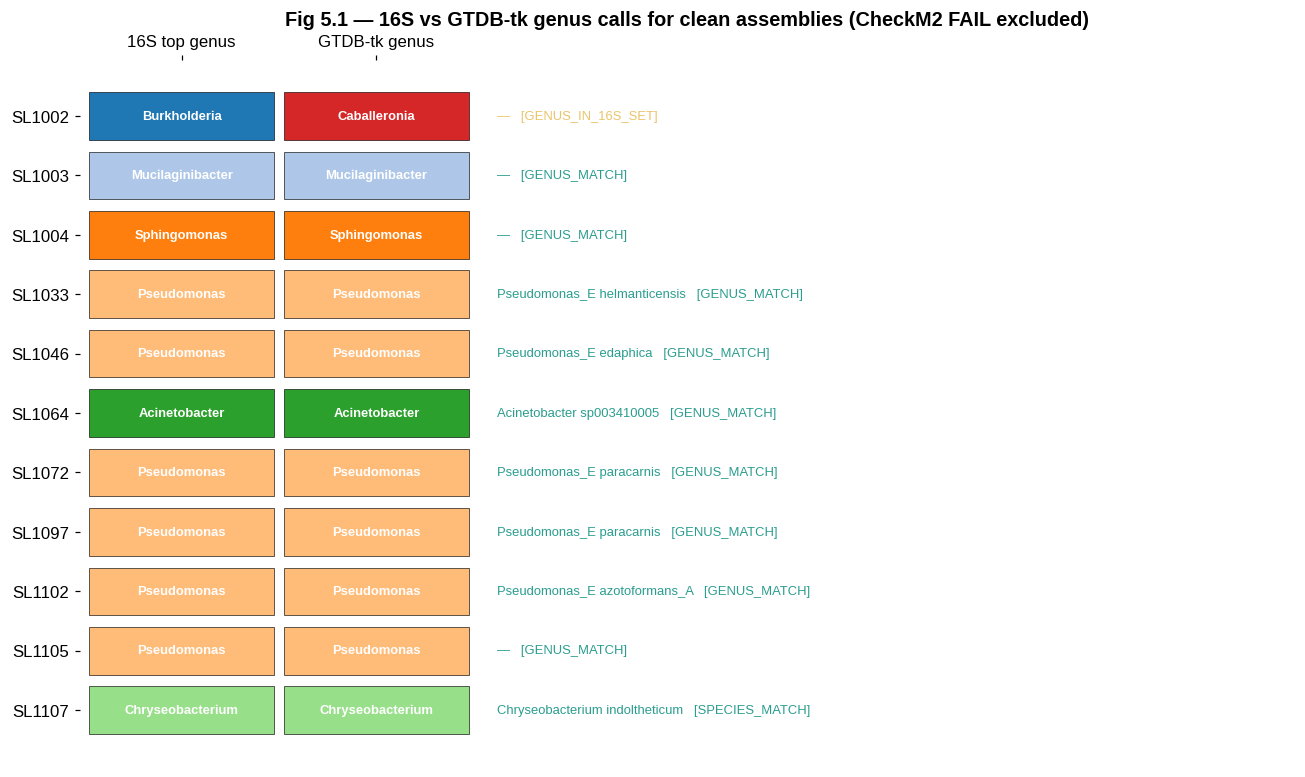

In [16]:
# Fig 5.1 — Per-sample 16S vs GTDB call, side by side
# Restricted to non-contaminated samples (CheckM2 PASS), since contaminated bins give mixed signals
# that aren't a fair test of either method.
cmp_s = (cmp[~cmp["contaminated"]]
         .sort_values(["agreement", "sample"])
         .reset_index(drop=True))

# Assign a color per genus (16S + GTDB together) so matching genera share a color
all_genera = pd.concat([cmp_s["top_genus_ge95pct"].fillna("(none)"),
                        cmp_s["genus_norm"].fillna("(none)")]).unique()
palette = sns.color_palette("tab20", n_colors=len(all_genera))
genus_color = dict(zip(all_genera, palette))
genus_color["(none)"] = "#cccccc"

fig, ax = plt.subplots(figsize=(12, 7.2))
for i, r in cmp_s.iterrows():
    g16 = r["top_genus_ge95pct"] if isinstance(r["top_genus_ge95pct"], str) and r["top_genus_ge95pct"] else "(none)"
    gdb = r["genus_norm"] if isinstance(r["genus_norm"], str) and r["genus_norm"] else "(none)"
    # 16S tile
    ax.barh(i, 1, left=0, color=genus_color.get(g16, "#cccccc"),
            edgecolor="black", linewidth=0.4)
    ax.text(0.5, i, g16, ha="center", va="center", fontsize=8.5,
            color="white", fontweight="bold")
    # GTDB tile
    edge = C_FAIL if r["contaminated"] else "black"
    lw = 2.0 if r["contaminated"] else 0.4
    ax.barh(i, 1, left=1.05, color=genus_color.get(gdb, "#cccccc"),
            edgecolor=edge, linewidth=lw)
    ax.text(1.55, i, gdb, ha="center", va="center", fontsize=8.5,
            color="white", fontweight="bold")
    # Species / agreement label
    sp = r["species"] if isinstance(r["species"], str) and r["species"].strip() else "—"
    agree = r["agreement"]
    agree_color = {
        "SPECIES_MATCH": C_PASS,
        "GENUS_MATCH": C_PASS,
        "GENUS_IN_16S_SET": C_WARN,
        "DISAGREE": C_FAIL,
        "NO_16S": "#888888",
        "ARCHAEA/NOVELTY": "#6a0572",
    }.get(agree, "black")
    tag = "  ⚠ CONTAM" if r["contaminated"] else ""
    ax.text(2.2, i, "{}   [{}]{}".format(sp, agree, tag),
            va="center", fontsize=8.5, color=agree_color,
            fontweight=("bold" if agree in ("DISAGREE", "ARCHAEA/NOVELTY") or r["contaminated"] else "normal"))

ax.set_yticks(range(len(cmp_s)))
ax.set_yticklabels(cmp_s["sample"])
ax.set_xticks([0.5, 1.55])
ax.set_xticklabels(["16S top genus", "GTDB-tk genus"])
ax.set_xlim(-0.05, 6.5)
ax.set_title("Fig 5.1 — 16S vs GTDB-tk genus calls for clean assemblies (CheckM2 FAIL excluded)")
ax.invert_yaxis()
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
plt.savefig(FIGS / "fig5_1_16s_vs_gtdbtk.png")
plt.show()


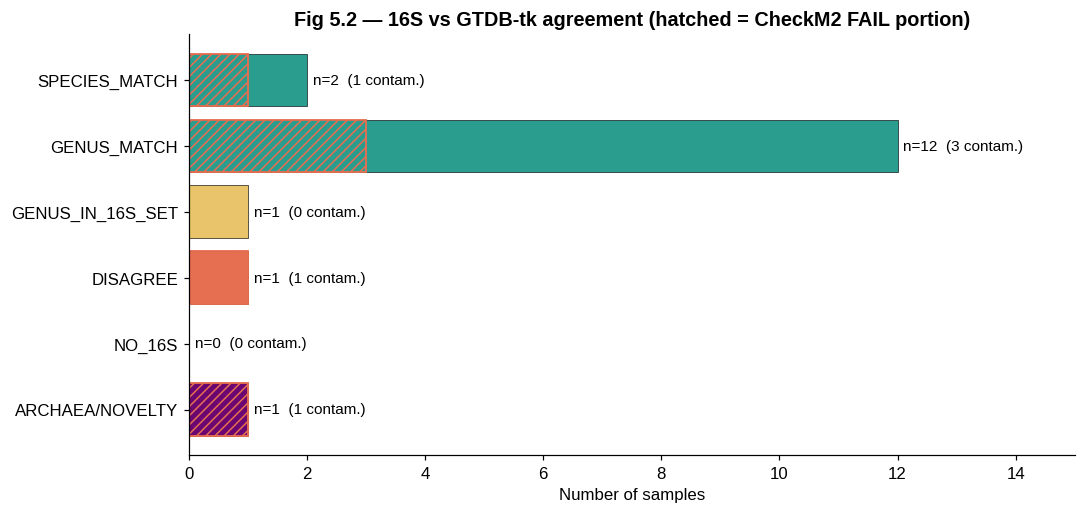

In [17]:
# Fig 5.2 — Agreement distribution
order = ["SPECIES_MATCH", "GENUS_MATCH", "GENUS_IN_16S_SET",
         "DISAGREE", "NO_16S", "ARCHAEA/NOVELTY"]
counts = cmp["agreement"].value_counts().reindex(order, fill_value=0)
contam_counts = cmp[cmp["contaminated"]]["agreement"].value_counts().reindex(order, fill_value=0)

colors_row = [C_PASS, C_PASS, C_WARN, C_FAIL, "#888888", "#6a0572"]

fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(order))
bars = ax.barh(y, counts.values, color=colors_row, edgecolor="black", linewidth=0.4)
# Hatch overlay for contaminated portion
for bar, total, contam in zip(bars, counts.values, contam_counts.values):
    if contam > 0:
        ax.barh(bar.get_y() + bar.get_height()/2, contam, height=bar.get_height(),
                color="none", edgecolor=C_FAIL, hatch="////", linewidth=1.2, align="center")
    ax.text(total + 0.1, bar.get_y() + bar.get_height()/2,
            "n={}  ({} contam.)".format(int(total), int(contam)),
            va="center", fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel("Number of samples")
ax.set_title("Fig 5.2 — 16S vs GTDB-tk agreement (hatched = CheckM2 FAIL portion)")
ax.invert_yaxis()
ax.set_xlim(0, counts.max() + 3)
plt.tight_layout()
plt.savefig(FIGS / "fig5_2_agreement.png")
plt.show()


In [18]:
# Table 5.1 — 16S vs GTDB-tk side-by-side, with contamination & agreement
tab5 = cmp[["sample", "top_genus_ge95pct", "top_genus_pct_of_hits_ge95pct",
            "top_species_ge97pct",
            "genus_norm", "species", "classification_method",
            "contaminated", "agreement"]].copy()
tab5.columns = ["sample", "16S_top_genus", "16S_top_genus_%",
                "16S_top_species_≥97%",
                "GTDB_genus", "GTDB_species", "GTDB_method",
                "contaminated", "agreement"]
tab5.to_csv(FIGS / "table5_1_16s_vs_gtdbtk.csv", index=False)
tab5.style.set_caption("Table 5.1 — 16S vs GTDB-tk call comparison per sample")


,sample,16S_top_genus,16S_top_genus_%,16S_top_species_≥97%,GTDB_genus,GTDB_species,GTDB_method,contaminated,agreement
0,SL1002,Burkholderia,70.800000,Burkholderia glumae,Caballeronia,nan,taxonomic classification defined by topology and ANI,False,GENUS_IN_16S_SET
1,SL1003,Mucilaginibacter,99.300000,Mucilaginibacter saanensis,Mucilaginibacter,nan,taxonomic classification defined by topology and ANI,False,GENUS_MATCH
2,SL1004,Sphingomonas,100.000000,Sphingomonas aerolata,Sphingomonas,nan,taxonomic classification defined by topology and ANI,False,GENUS_MATCH
3,SL1010,nan,nan,nan,nan,nan,taxonomic novelty determined using RED,True,ARCHAEA/NOVELTY
4,SL1033,Pseudomonas,99.000000,Pseudomonas fluorescens,Pseudomonas,Pseudomonas_E helmanticensis,ani_screen,False,GENUS_MATCH
5,SL1046,Pseudomonas,99.800000,Pseudomonas poae,Pseudomonas,Pseudomonas_E edaphica,ani_screen,False,GENUS_MATCH
6,SL1064,Acinetobacter,99.900000,Acinetobacter pittii,Acinetobacter,Acinetobacter sp003410005,ani_screen,False,GENUS_MATCH
7,SL1071,Pseudomonas,100.000000,nan,Acinetobacter,Acinetobacter sp003410005,ani_screen,True,DISAGREE
8,SL1072,Pseudomonas,99.900000,Pseudomonas poae,Pseudomonas,Pseudomonas_E paracarnis,ani_screen,False,GENUS_MATCH
9,SL1086,Pseudomonas,99.900000,Pseudomonas poae,Pseudomonas,Pseudomonas_E azotoformans_A,ani_screen,True,GENUS_MATCH


## 7. ANI to nearest GTDB reference — novelty gauge

FastANI distance to the nearest GTDB reference genome. The **95% ANI line** is the standard
species-delineation threshold: samples below it are candidate novel species.
Taken from GTDB-tk's raw `bac120.summary.tsv` (`closest_genome_ani`; fallback to `closest_placement_ani`
or the best `other_related_references` ANI for samples where FastANI didn't produce a species hit).


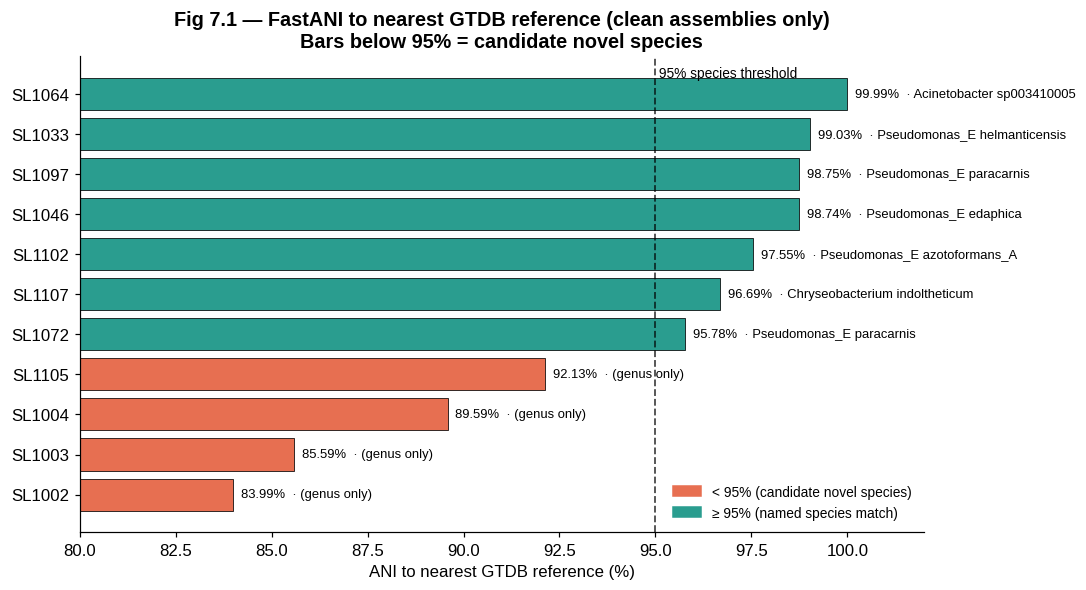

In [19]:
# Fig 7.1 — ANI to nearest GTDB reference per sample
raw = pd.read_csv(DATA / "wgs_gtdbtk/gtdbtk_raw/gtdbtk.bac120.summary.tsv", sep="\t")
raw = raw.rename(columns={"user_genome": "sample"})

other_col = "other_related_references(genome_id,species_name,radius,ANI,AF)"

def pick_ani(row):
    # 1) closest_genome_ani (direct FastANI species hit)
    for col, refcol in (("closest_genome_ani", "closest_genome_reference"),
                        ("closest_placement_ani", "closest_placement_reference")):
        val = row.get(col)
        if pd.notna(val) and str(val).strip() not in ("", "N/A"):
            try:
                return float(val), str(row.get(refcol, "")), col
            except ValueError:
                pass
    # 2) fall back to best entry in other_related_references
    other = row.get(other_col, "")
    if isinstance(other, str) and other.strip() not in ("", "N/A"):
        first = other.split(";")[0].strip()
        parts = [p.strip() for p in first.split(",")]
        if len(parts) >= 4:
            try:
                return float(parts[3]), parts[0] + " (" + parts[1] + ")", "other_related_references"
            except ValueError:
                pass
    return None, None, None

recs = []
for _, r in raw.iterrows():
    ani, ref, source = pick_ani(r)
    recs.append({"sample": r["sample"], "ani": ani, "ref": ref, "source": source})
ani_df = pd.DataFrame(recs)

# Merge flags
ani_df = (ani_df.merge(checkm2[["sample", "qc_flag"]], on="sample", how="left")
                .merge(cmp[["sample", "species", "genus_norm"]], on="sample", how="left"))
ani_df["contaminated"] = ani_df["qc_flag"] == "FAIL"

# Drop contaminated samples for a clean novelty picture; sort ANI ascending (novel first)
ani_df = (ani_df.dropna(subset=["ani"])
                .query("not contaminated")
                .sort_values("ani"))

# Color: below 95% → candidate novel (orange), at/above 95% → named (teal)
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = np.where(ani_df["ani"] < 95.0, "#e76f51", C_PASS)
bars = ax.barh(ani_df["sample"], ani_df["ani"],
               color=colors, edgecolor="black", linewidth=0.5)

# 95% species-threshold line
ax.axvline(95, ls="--", color="black", alpha=0.7, linewidth=1.2)
ax.text(95, len(ani_df) - 0.3, " 95% species threshold",
        fontsize=9, va="top", ha="left")

# Value labels + species / reference on each bar
for bar, (_, r) in zip(bars, ani_df.iterrows()):
    sp = r["species"] if isinstance(r["species"], str) and r["species"].strip() else "(genus only)"
    ax.text(r["ani"] + 0.2, bar.get_y() + bar.get_height()/2,
            "{:.2f}%  · {}".format(r["ani"], sp),
            va="center", fontsize=8.5)

ax.set_xlim(80, 102)
ax.set_xlabel("ANI to nearest GTDB reference (%)")
ax.set_title("Fig 7.1 — FastANI to nearest GTDB reference (clean assemblies only)\nBars below 95% = candidate novel species")

handles = [
    mpatches.Patch(color="#e76f51", label="< 95% (candidate novel species)"),
    mpatches.Patch(color=C_PASS,    label="≥ 95% (named species match)"),
]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fig7_1_ani_to_nearest.png")
plt.show()

# CSV
ani_df[["sample", "ani", "species", "ref", "source", "contaminated"]].to_csv(
    FIGS / "table7_1_ani_to_nearest.csv", index=False)


## 6. Discovery application — banana-slug strains via IDBac contrastive transformer

*Schematic figures illustrating the results paragraph:* 17 strains → CheckM2 filter → 11 retained →
queried against IDBac with our contrastive-transformer search → 6 returned hits at threshold 0.232 →
4 of those 6 had a correct top-1, 2 had incorrect top-1 but were rescued by consensus of subsequent hits
(SL1072: 32/35 subsequent correct; SL1033: 8/8 subsequent correct).

**Note on the tiles in Fig 6.1 (right panel):** the exact ordering of individual hits is schematic —
it encodes the counts given in the text (32/35 correct for SL1072, 8/8 for SL1033, top-1 correct for the
other four), not an actual hit-by-hit sequence. Swap in raw IDBac hit data if available.


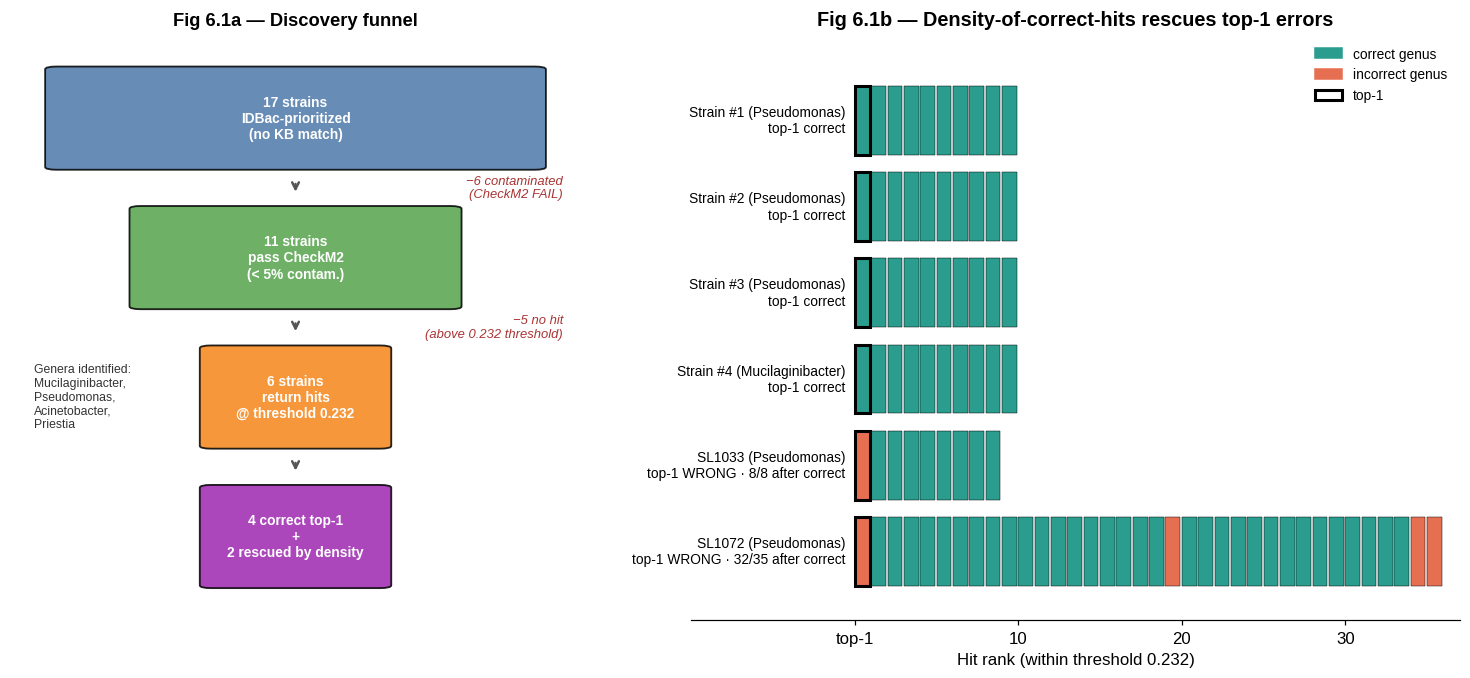

In [20]:
# Fig 6.1 — Two-panel: discovery funnel (left) + per-strain hit density (right)
from matplotlib.patches import FancyBboxPatch

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13.5, 6.3),
                                 gridspec_kw={"width_ratios": [1.0, 1.35]})

# -------- LEFT: funnel --------
stages = [
    ("17 strains\nIDBac-prioritized\n(no KB match)", "#4c78a8", 17),
    ("11 strains\npass CheckM2\n(< 5% contam.)", "#54a24b", 11),
    ("6 strains\nreturn hits\n@ threshold 0.232", "#f58518", 6),
    ("4 correct top-1\n+\n2 rescued by density", "#9c27b0", 6),
]
# Draw trapezoidal stacked boxes
widths = [w for _, _, w in stages]
max_w = max(widths)
y_pos = np.arange(len(stages))[::-1]
for i, ((label, color, n), y) in enumerate(zip(stages, y_pos)):
    half = (n / max_w) * 0.42
    box = FancyBboxPatch((0.5 - half, y - 0.35), 2 * half, 0.7,
                         boxstyle="round,pad=0.02", linewidth=1.2,
                         facecolor=color, edgecolor="black", alpha=0.85)
    ax_l.add_patch(box)
    ax_l.text(0.5, y, label, ha="center", va="center",
              fontsize=9, color="white", fontweight="bold")
    # Arrow to next stage
    if i < len(stages) - 1:
        ax_l.annotate("", xy=(0.5, y - 0.55), xytext=(0.5, y - 0.45),
                      arrowprops=dict(arrowstyle="->", color="#555", lw=1.6))

# Attrition annotations on the right side
attrition = [
    (2.5, "−6 contaminated\n(CheckM2 FAIL)"),
    (1.5, "−5 no hit\n(above 0.232 threshold)"),
]
for y, txt in attrition:
    ax_l.text(0.97, y, txt, ha="right", va="center",
              fontsize=8.5, color="#a33", style="italic")

# Genera annotation at the "6 strains with hits" stage
ax_l.text(0.04, 1.0, "Genera identified:\nMucilaginibacter,\nPseudomonas,\nAcinetobacter,\nPriestia",
          ha="left", va="center", fontsize=8, color="#333")

ax_l.set_xlim(0, 1)
ax_l.set_ylim(-0.6, 3.6)
ax_l.set_xticks([]); ax_l.set_yticks([])
ax_l.set_title("Fig 6.1a — Discovery funnel", fontsize=12)
for spine in ax_l.spines.values():
    spine.set_visible(False)

# -------- RIGHT: per-strain hit tile density --------
# Rows: 6 strains that returned hits. Each row is a strip of tiles
# (leftmost = top-1). Green = correct genus; red = incorrect.
# Numbers below are taken from the text; positions of the reds in SL1072 are
# schematic (text only gives 32/35 correct).
strains = [
    # (row label, list of ints 1=correct, 0=incorrect)
    ("Strain #1 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #2 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #3 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #4 (Mucilaginibacter)\ntop-1 correct", [1] * 10),
    ("SL1033 (Pseudomonas)\ntop-1 WRONG · 8/8 after correct",
         [0] + [1] * 8),
    ("SL1072 (Pseudomonas)\ntop-1 WRONG · 32/35 after correct",
         [0] + [1]*18 + [0] + [1]*14 + [0, 0]),
]

max_len = max(len(h) for _, h in strains)
tile_h = 0.8
for i, (label, hits) in enumerate(strains):
    y = len(strains) - 1 - i
    for j, h in enumerate(hits):
        color = C_PASS if h == 1 else C_FAIL
        ax_r.add_patch(plt.Rectangle((j, y - tile_h/2), 0.9, tile_h,
                                     facecolor=color, edgecolor="black", linewidth=0.3))
    # Highlight top-1 with a thicker border
    top_color = C_PASS if hits[0] == 1 else C_FAIL
    ax_r.add_patch(plt.Rectangle((0, y - tile_h/2), 0.9, tile_h,
                                 facecolor="none", edgecolor="black", linewidth=2.0))
    ax_r.text(-0.6, y, label, ha="right", va="center", fontsize=9)

# Axis cosmetics
ax_r.set_xlim(-10, max_len + 1)
ax_r.set_ylim(-0.8, len(strains))
ax_r.set_yticks([])
ax_r.set_xticks([0, 10, 20, 30])
ax_r.set_xticklabels(["top-1", "10", "20", "30"])
ax_r.set_xlabel("Hit rank (within threshold 0.232)")
ax_r.set_title("Fig 6.1b — Density-of-correct-hits rescues top-1 errors")
for spine in ("top", "left", "right"):
    ax_r.spines[spine].set_visible(False)

# Legend
handles = [
    mpatches.Patch(color=C_PASS, label="correct genus"),
    mpatches.Patch(color=C_FAIL, label="incorrect genus"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2.0, label="top-1"),
]
ax_r.legend(handles=handles, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / "fig6_1_discovery_funnel_density.png")
plt.show()


SL1003  true=Mucilaginibacter    n_hits=2  correct=1/2
SL1097  true=Pseudomonas         n_hits=71  correct=60/71
SL1102  true=Pseudomonas         n_hits=4  correct=4/4
SL1105  true=Pseudomonas         n_hits=62  correct=57/62
SL1033  true=Pseudomonas         n_hits=10  correct=9/10
SL1072  true=Pseudomonas         n_hits=36  correct=33/36


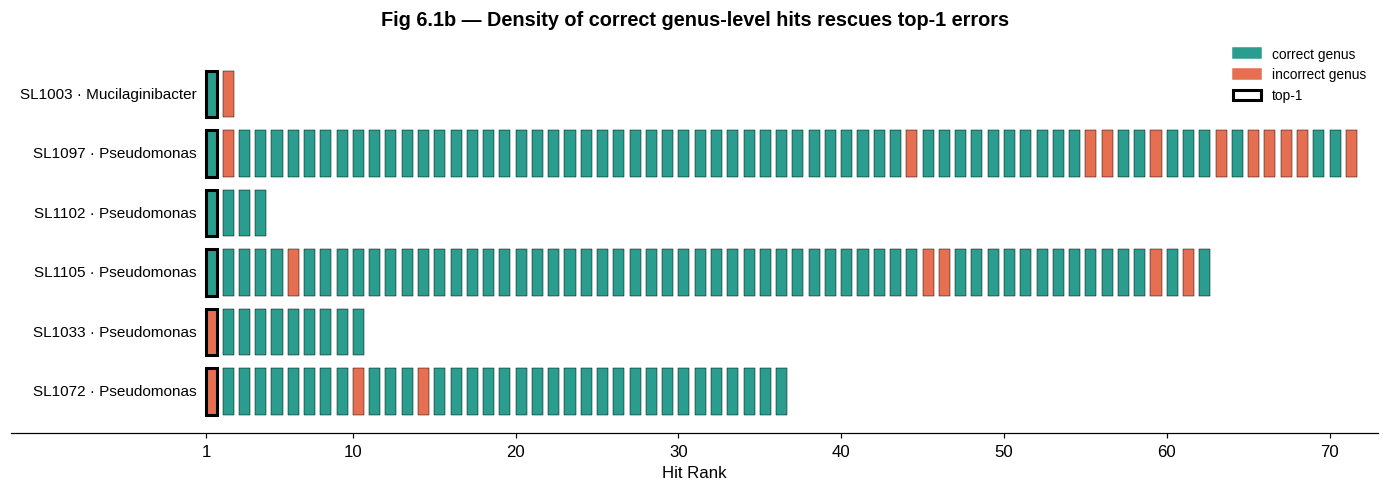

In [21]:
# Fig 6.1b — real IDBac hit data from enriched_db_results.tsv
idbac = pd.read_csv(DATA / "idbac/enriched_db_results.tsv", sep="\t")
idbac["sl"] = idbac["query_filename"].str.extract(r"(SL\d+)")
hits = idbac[idbac["distance"] <= 0.232].copy()

# The 6 strains that returned hits in the banana-slug cohort, in the order used for the figure.
# True genus taken from GTDB-tk (normalized).
STRAINS_6 = [
    ("SL1003", "Mucilaginibacter"),  # correct top-1
    ("SL1097", "Pseudomonas"),       # correct top-1
    ("SL1102", "Pseudomonas"),       # correct top-1
    ("SL1105", "Pseudomonas"),       # correct top-1
    ("SL1033", "Pseudomonas"),       # WRONG top-1 (Priestia), rescued by density
    ("SL1072", "Pseudomonas"),       # WRONG top-1 (Acinetobacter), rescued by density
]

# Rank hits per strain by ascending distance; mark each "correct" if hit genus == true genus.
per_strain = {}
for sl, true_genus in STRAINS_6:
    sub = (hits[hits["sl"] == sl]
           .sort_values("distance")
           .reset_index(drop=True))
    per_strain[sl] = [int(g == true_genus) for g in sub["db_genus"]]
    print("{:>6}  true={:<18}  n_hits={}  correct={}/{}".format(
        sl, true_genus, len(sub), sum(per_strain[sl]), len(sub)))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(13, 4.6))

max_len = max(len(h) for h in per_strain.values())
tile_h = 0.78
tile_w = 0.68   # more space between tiles (gap ≈ 0.32)

for i, (sl, true_genus) in enumerate(STRAINS_6):
    hit_row = per_strain[sl]
    y = len(STRAINS_6) - 1 - i
    for j, h in enumerate(hit_row):
        color = C_PASS if h == 1 else C_FAIL
        ax.add_patch(plt.Rectangle((j, y - tile_h/2), tile_w, tile_h,
                                   facecolor=color, edgecolor="black", linewidth=0.3))
    # Thicker border on the top-1 tile
    ax.add_patch(plt.Rectangle((0, y - tile_h/2), tile_w, tile_h,
                               facecolor="none", edgecolor="black", linewidth=2.0))
    ax.text(-0.6, y, "{} · {}".format(sl, true_genus),
            ha="right", va="center", fontsize=10)

ax.set_xlim(-12, max_len + 1)
ax.set_ylim(-0.7, len(STRAINS_6))
ax.set_yticks([])
# X-ticks every 10 hits (rank 1, 10, 20, ...)
tick_positions = [0] + list(range(9, max_len, 10))
tick_labels    = [str(p + 1) for p in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Hit Rank")
ax.set_title("Fig 6.1b — Density of correct genus-level hits rescues top-1 errors")
for s in ("top", "left", "right"):
    ax.spines[s].set_visible(False)

handles = [
    mpatches.Patch(color=C_PASS, label="correct genus"),
    mpatches.Patch(color=C_FAIL, label="incorrect genus"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2.0, label="top-1"),
]
ax.legend(handles=handles, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fig6_1b_density.png")
plt.show()


In [22]:
# Paper-figure candidates for Fig 6.1b. Saved to notebooks/figures/fig6_iterations/
# so we can iterate without overwriting earlier versions.
FIG_ITER = FIGS / "fig6_iterations"
FIG_ITER.mkdir(exist_ok=True)

# Recompute per-strain ranked hit genera and correctness
STRAINS_6 = [
    ("SL1033", "Pseudomonas"),    # rescue case — put first for paper
    ("SL1072", "Pseudomonas"),    # rescue case
    ("SL1003", "Mucilaginibacter"),
    ("SL1097", "Pseudomonas"),
    ("SL1102", "Pseudomonas"),
    ("SL1105", "Pseudomonas"),
]

def strain_hits(sl):
    return (hits[hits["sl"] == sl].sort_values("distance")
            .reset_index(drop=True)["db_genus"].tolist())

per_strain = {sl: strain_hits(sl) for sl, _ in STRAINS_6}
per_strain_correct = {sl: [int(g == true_g) for g in per_strain[sl]]
                      for sl, true_g in STRAINS_6}
per_strain_precision = {sl: (sum(hits_bool) / len(hits_bool) if hits_bool else 0.0)
                        for sl, hits_bool in per_strain_correct.items()}


<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1360384/448910966.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.text(-0.6, y, "{} · $\mathit{{{}}}$".format(sl, true_g),


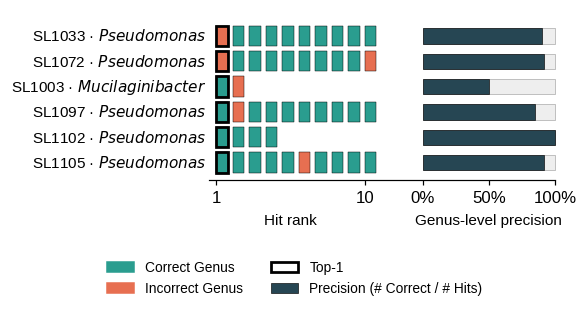

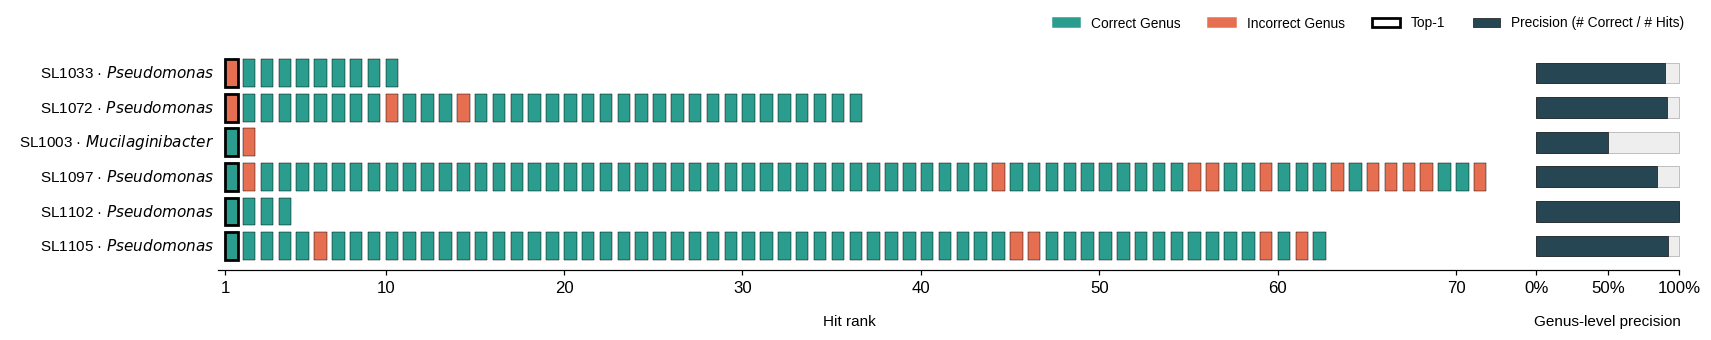

In [23]:
# Variant A — tiles + right-hand precision gauge
# Rendered twice: top-10 (for main text) and all hits (for SI).
def plot_tiles_with_gauge(limit, fname, title, fig_w, show_title=True, legend_below=False):
    tile_h = 0.80
    tile_w = 0.70            # generous gap between tiles
    gauge_gap = 2.5           # gap between tile area and gauge
    gauge_w = 8.0             # gauge axis width in data units
    # x extent of gauge = [gauge_x0, gauge_x0 + gauge_w]
    gauge_x0 = limit + gauge_gap
    gauge_x1 = gauge_x0 + gauge_w

    fig, ax = plt.subplots(figsize=(fig_w, 3.4))
    for i, (sl, true_g) in enumerate(STRAINS_6):
        y = len(STRAINS_6) - 1 - i
        corr = per_strain_correct[sl]
        show = corr[:limit]
        # Tiles
        for j, h in enumerate(show):
            color = C_PASS if h == 1 else C_FAIL
            ax.add_patch(plt.Rectangle((j, y - tile_h/2), tile_w, tile_h,
                                       facecolor=color, edgecolor="black", linewidth=0.3))
        # Thick border on top-1 tile
        ax.add_patch(plt.Rectangle((0, y - tile_h/2), tile_w, tile_h,
                                   facecolor="none", edgecolor="black", linewidth=1.8))

        # Row label — italicize the genus only
        ax.text(-0.6, y, "{} · $\mathit{{{}}}$".format(sl, true_g),
                ha="right", va="center", fontsize=10)

        # Precision gauge (horizontal bar from gauge_x0 to gauge_x0 + gauge_w * precision)
        prec = per_strain_precision[sl]
        ax.add_patch(plt.Rectangle((gauge_x0, y - tile_h/2 * 0.75),
                                   gauge_w, tile_h * 0.75,
                                   facecolor="#eeeeee", edgecolor="#bbb", linewidth=0.6))
        ax.add_patch(plt.Rectangle((gauge_x0, y - tile_h/2 * 0.75),
                                   gauge_w * prec, tile_h * 0.75,
                                   facecolor="#264653", edgecolor="black", linewidth=0.4))

    # Axis cosmetics
    ax.set_ylim(-0.7, len(STRAINS_6))
    ax.set_xlim(-12, gauge_x1 + 1)
    ax.set_yticks([])

    # X ticks — two groups: hit rank on the left, 0-100% for gauge on the right
    rank_ticks = [0] + list(range(9, limit, 10))
    rank_labels = [str(p + 1) for p in rank_ticks]
    # gauge ticks
    gauge_ticks  = [gauge_x0, gauge_x0 + gauge_w/2, gauge_x0 + gauge_w]
    gauge_labels = ["0%", "50%", "100%"]

    ax.set_xticks(rank_ticks + gauge_ticks)
    ax.set_xticklabels(rank_labels + gauge_labels)

    # Split x-axis labels: below the tiles say "Hit rank", below the gauges say "Precision"
    ax.text(limit / 2 - 0.5, -2.0, "Hit rank",
            ha="center", va="top", fontsize=10)
    ax.text(gauge_x0 + gauge_w / 2, -2.0, "Genus-level precision",
            ha="center", va="top", fontsize=10)

    if show_title:
        ax.set_title(title, fontsize=12)
    for s in ("top", "left", "right"):
        ax.spines[s].set_visible(False)
    # Shorten the visible bottom spine to avoid it running past the gauges
    ax.spines["bottom"].set_bounds(-0.4, gauge_x1)

    # Legend
    handles = [
        mpatches.Patch(color=C_PASS, label="Correct Genus"),
        mpatches.Patch(color=C_FAIL, label="Incorrect Genus"),
        mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.8, label="Top-1"),
        mpatches.Patch(facecolor="#264653", edgecolor="black", linewidth=0.4,
                       label="Precision (# Correct / # Hits)"),
    ]
    if legend_below:
        ax.legend(handles=handles, loc="upper center",
                  bbox_to_anchor=(0.5, -0.40), ncol=2, fontsize=9, frameon=False)
    else:
        ax.legend(handles=handles, loc="upper right",
                  bbox_to_anchor=(1.0, 1.15), ncol=4, fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_ITER / fname)
    plt.show()

# Main-text candidate: top-10 view.
# fig_w chosen so inch-per-data-unit matches the all-hits version
# (16 in / 94.5 x-units ≈ 0.169 in/unit; top-10 xlim spans 33.5 units → ~5.7 in)
plot_tiles_with_gauge(limit=10,
                       fname="tiles_top10_with_precision_gauge.png",
                       title="",
                       fig_w=5.7,
                       show_title=False,
                       legend_below=True)

# SI candidate: all hits
max_hits = max(len(per_strain_correct[sl]) for sl, _ in STRAINS_6)
plot_tiles_with_gauge(limit=max_hits,
                       fname="tiles_all_hits_with_precision_gauge.png",
                       title="",
                       fig_w=16,
                       show_title=False)


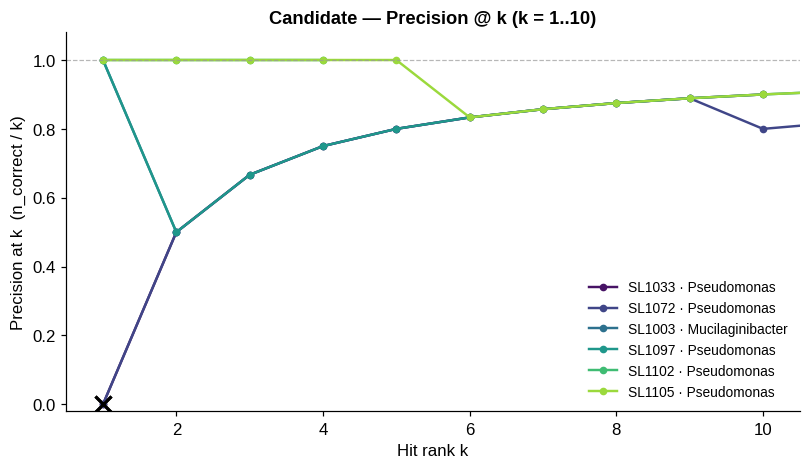

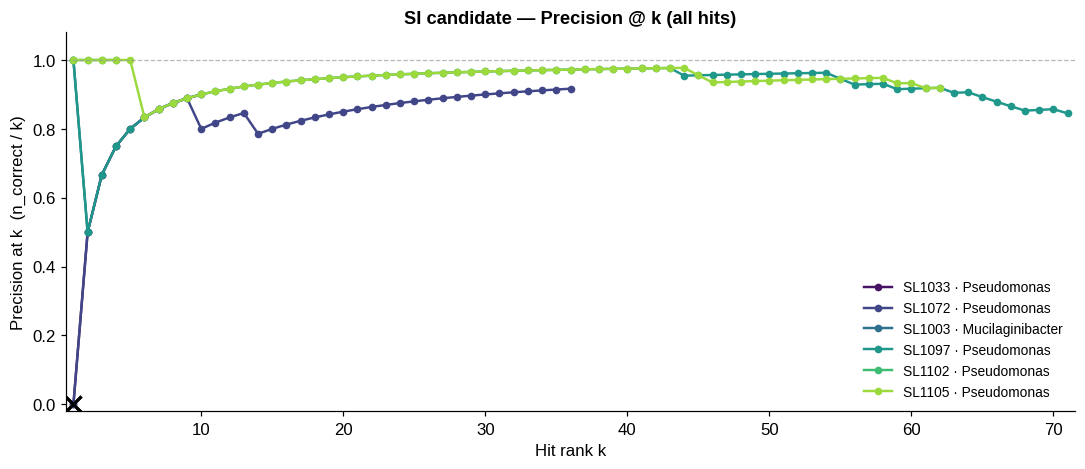

In [24]:
# Variant B — Precision@k line plot
# Per-strain: y = (# correct in top-k) / k, for k = 1 .. n_hits
import itertools

def plot_precision_at_k(xlim_max, fname, title, fig_w):
    fig, ax = plt.subplots(figsize=(fig_w, 4.4))
    color_cycle = plt.cm.viridis(np.linspace(0.05, 0.85, len(STRAINS_6)))

    for (sl, true_g), color in zip(STRAINS_6, color_cycle):
        corr = per_strain_correct[sl]
        n = len(corr)
        ks = np.arange(1, n + 1)
        cum = np.cumsum(corr)
        prec_at_k = cum / ks
        ax.plot(ks, prec_at_k, "-o", color=color, linewidth=1.6,
                markersize=4, label="{} · {}".format(sl, true_g))
        # Emphasize top-1 point if wrong (distinct marker)
        if corr[0] == 0:
            ax.plot(1, prec_at_k[0], marker="x", markersize=10,
                    markeredgewidth=2, color="black")

    # Reference line at 1.0
    ax.axhline(1.0, ls="--", color="#999", linewidth=0.8, alpha=0.7)

    ax.set_xlim(0.5, xlim_max + 0.5)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel("Hit rank k")
    ax.set_ylabel("Precision at k  (n_correct / k)")
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower right", fontsize=9, frameon=False)
    plt.tight_layout()
    plt.savefig(FIG_ITER / fname)
    plt.show()

plot_precision_at_k(xlim_max=10, fig_w=7.5,
                     fname="precision_at_k_top10.png",
                     title="Candidate — Precision @ k (k = 1..10)")
plot_precision_at_k(xlim_max=max_hits, fig_w=10,
                     fname="precision_at_k_all.png",
                     title="SI candidate — Precision @ k (all hits)")


At default threshold 0.232: n=185, precision=0.886


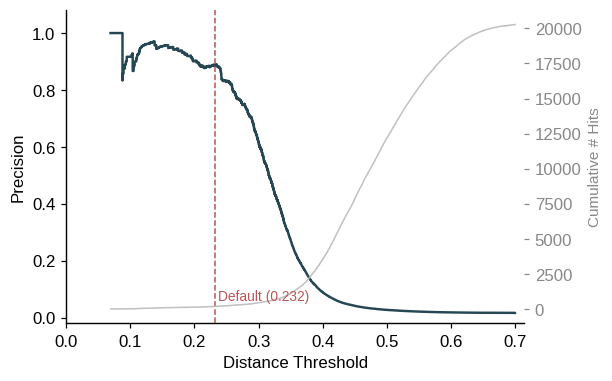

In [25]:
# Variant C — Threshold vs. pooled precision across the 6 banana-slug strains.
# Uses the full idbac table (unfiltered by the 0.232 default cutoff) so we can see
# how genus-level precision degrades as the distance threshold is relaxed.
sl_to_true = dict(STRAINS_6)
scope = idbac[idbac["sl"].isin(sl_to_true)].copy()
scope["true_g"] = scope["sl"].map(sl_to_true)
scope["correct"] = (scope["db_genus"] == scope["true_g"]).astype(int)
scope = scope.sort_values("distance").reset_index(drop=True)
scope["n_cum"] = np.arange(1, len(scope) + 1)
scope["k_cum"] = scope["correct"].cumsum()
scope["precision"] = scope["k_cum"] / scope["n_cum"]

DEFAULT_T = 0.232
at_default = scope[scope["distance"] <= DEFAULT_T]
if len(at_default):
    n_def = len(at_default)
    p_def = at_default["correct"].sum() / n_def
    print("At default threshold {:.3f}: n={}, precision={:.3f}".format(DEFAULT_T, n_def, p_def))

fig, ax = plt.subplots(figsize=(5.7, 3.6))
ax.step(scope["distance"], scope["precision"], where="post",
        color="#264653", linewidth=1.6, zorder=3)
ax.axvline(DEFAULT_T, ls="--", color="#b55", linewidth=1.0, zorder=4)

ax2 = ax.twinx()
ax2.step(scope["distance"], scope["n_cum"], where="post",
         color="#bbb", linewidth=1.0, alpha=0.9, zorder=2)
# Put the annotation on ax2 with high zorder so it sits in front of both lines.
ax2.text(DEFAULT_T + 0.005, 0.05, "Default (0.232)",
         color="#b55", ha="left", va="bottom", fontsize=9,
         transform=ax.transData, zorder=10)
ax2.set_ylabel("Cumulative # Hits", fontsize=10, color="#888")
ax2.tick_params(axis="y", colors="#888")
ax2.spines["top"].set_visible(False)

ax.set_xlim(0, scope["distance"].max() * 1.02)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel("Distance Threshold")
ax.set_ylabel("Precision")
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_ITER / "threshold_vs_precision.png")
plt.show()


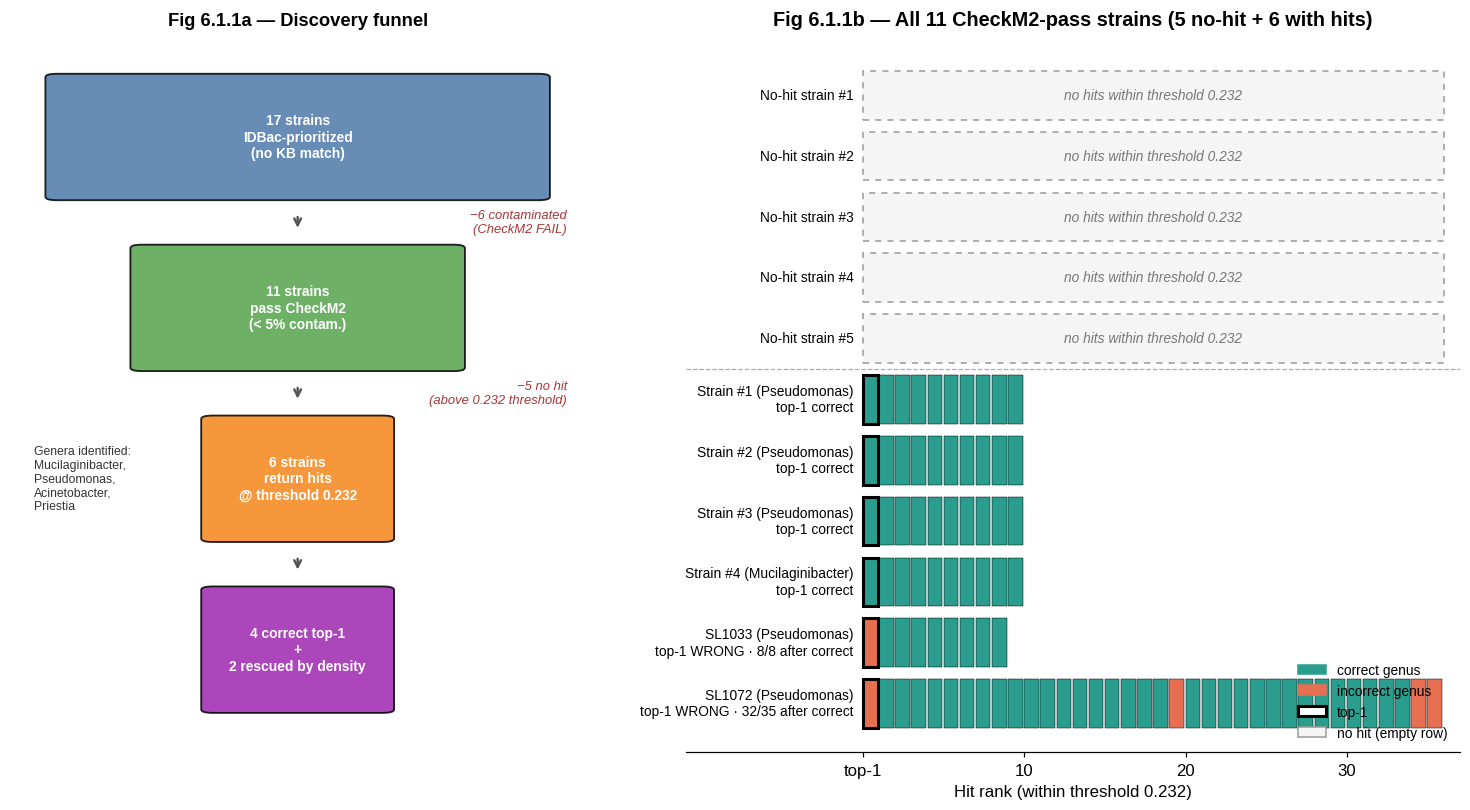

In [26]:
# Fig 6.1.1 — Honest version: show the 5 no-hit strains alongside the 6 hit strains
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13.5, 7.5),
                                 gridspec_kw={"width_ratios": [1.0, 1.35]})

# -------- LEFT: same funnel as 6.1 --------
stages_1 = [
    ("17 strains\nIDBac-prioritized\n(no KB match)", "#4c78a8", 17),
    ("11 strains\npass CheckM2\n(< 5% contam.)", "#54a24b", 11),
    ("6 strains\nreturn hits\n@ threshold 0.232", "#f58518", 6),
    ("4 correct top-1\n+\n2 rescued by density", "#9c27b0", 6),
]
widths = [w for _, _, w in stages_1]
max_w = max(widths)
y_pos = np.arange(len(stages_1))[::-1]
for i, ((label, color, n), y) in enumerate(zip(stages_1, y_pos)):
    half = (n / max_w) * 0.42
    box = FancyBboxPatch((0.5 - half, y - 0.35), 2 * half, 0.7,
                         boxstyle="round,pad=0.02", linewidth=1.2,
                         facecolor=color, edgecolor="black", alpha=0.85)
    ax_l.add_patch(box)
    ax_l.text(0.5, y, label, ha="center", va="center",
              fontsize=9, color="white", fontweight="bold")
    if i < len(stages_1) - 1:
        ax_l.annotate("", xy=(0.5, y - 0.55), xytext=(0.5, y - 0.45),
                      arrowprops=dict(arrowstyle="->", color="#555", lw=1.6))

for y, txt in [(2.5, "−6 contaminated\n(CheckM2 FAIL)"),
               (1.5, "−5 no hit\n(above 0.232 threshold)")]:
    ax_l.text(0.97, y, txt, ha="right", va="center",
              fontsize=8.5, color="#a33", style="italic")
ax_l.text(0.04, 1.0, "Genera identified:\nMucilaginibacter,\nPseudomonas,\nAcinetobacter,\nPriestia",
          ha="left", va="center", fontsize=8, color="#333")

ax_l.set_xlim(0, 1); ax_l.set_ylim(-0.6, 3.6)
ax_l.set_xticks([]); ax_l.set_yticks([])
ax_l.set_title("Fig 6.1.1a — Discovery funnel", fontsize=12)
for s in ax_l.spines.values():
    s.set_visible(False)

# -------- RIGHT: 11 rows total (5 no-hit + 6 hit) --------
# No-hit strains: empty rows with a dashed box and "no hit within threshold" note.
# Ordering: no-hit rows on top, then correct top-1, then rescued.
strains_all = [
    ("No-hit strain #1", None),
    ("No-hit strain #2", None),
    ("No-hit strain #3", None),
    ("No-hit strain #4", None),
    ("No-hit strain #5", None),
    ("Strain #1 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #2 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #3 (Pseudomonas)\ntop-1 correct",      [1] * 10),
    ("Strain #4 (Mucilaginibacter)\ntop-1 correct", [1] * 10),
    ("SL1033 (Pseudomonas)\ntop-1 WRONG · 8/8 after correct",
         [0] + [1] * 8),
    ("SL1072 (Pseudomonas)\ntop-1 WRONG · 32/35 after correct",
         [0] + [1]*18 + [0] + [1]*14 + [0, 0]),
]

max_len = 36  # cover longest row
tile_h = 0.8
for i, (label, hits) in enumerate(strains_all):
    y = len(strains_all) - 1 - i
    if hits is None:
        # Empty dashed placeholder indicating no hits within threshold
        ax_r.add_patch(plt.Rectangle((0, y - tile_h/2), max_len, tile_h,
                                     facecolor="#f5f5f5", edgecolor="#999",
                                     linestyle=(0, (4, 4)), linewidth=1.0))
        ax_r.text(max_len/2, y, "no hits within threshold 0.232",
                  ha="center", va="center", fontsize=9,
                  color="#777", style="italic")
    else:
        for j, h in enumerate(hits):
            color = C_PASS if h == 1 else C_FAIL
            ax_r.add_patch(plt.Rectangle((j, y - tile_h/2), 0.9, tile_h,
                                         facecolor=color, edgecolor="black", linewidth=0.3))
        # Thicker border on top-1
        ax_r.add_patch(plt.Rectangle((0, y - tile_h/2), 0.9, tile_h,
                                     facecolor="none", edgecolor="black", linewidth=2.0))
    ax_r.text(-0.6, y, label, ha="right", va="center", fontsize=9)

# Separator between no-hit and hit groups
ax_r.axhline(len(strains_all) - 5 - 0.5, color="#aaa", linestyle="--", linewidth=0.8)

ax_r.set_xlim(-11, max_len + 1)
ax_r.set_ylim(-0.8, len(strains_all))
ax_r.set_yticks([])
ax_r.set_xticks([0, 10, 20, 30])
ax_r.set_xticklabels(["top-1", "10", "20", "30"])
ax_r.set_xlabel("Hit rank (within threshold 0.232)")
ax_r.set_title("Fig 6.1.1b — All 11 CheckM2-pass strains (5 no-hit + 6 with hits)")
for s in ("top", "left", "right"):
    ax_r.spines[s].set_visible(False)

handles = [
    mpatches.Patch(color=C_PASS, label="correct genus"),
    mpatches.Patch(color=C_FAIL, label="incorrect genus"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2.0, label="top-1"),
    mpatches.Patch(facecolor="#f5f5f5", edgecolor="#999", linewidth=1.0, label="no hit (empty row)"),
]
ax_r.legend(handles=handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / "fig6_1_1_discovery_with_no_hits.png")
plt.show()


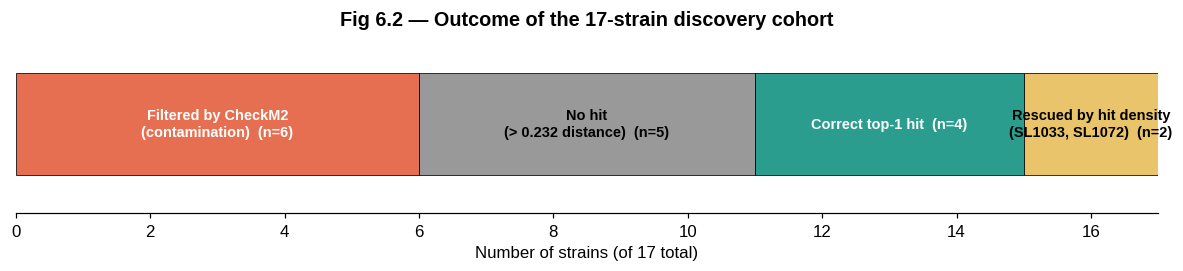

In [27]:
# Fig 6.2 — Compact outcome bar across the full 17-strain cohort
categories = [
    ("Filtered by CheckM2\n(contamination)", 6,  C_FAIL),
    ("No hit\n(> 0.232 distance)",           5,  "#999999"),
    ("Correct top-1 hit",                     4,  C_PASS),
    ("Rescued by hit density\n(SL1033, SL1072)", 2, C_WARN),
]
total = sum(n for _, n, _ in categories)

fig, ax = plt.subplots(figsize=(11, 2.6))
left = 0
for label, n, color in categories:
    ax.barh(0, n, left=left, color=color, edgecolor="black", linewidth=0.5)
    ax.text(left + n / 2, 0, "{}  (n={})".format(label, n),
            ha="center", va="center", fontsize=9.5,
            color=("white" if color in (C_FAIL, C_PASS) else "black"),
            fontweight="bold")
    left += n

ax.set_xlim(0, total)
ax.set_ylim(-0.7, 0.7)
ax.set_yticks([])
ax.set_xlabel("Number of strains (of 17 total)")
ax.set_title("Fig 6.2 — Outcome of the 17-strain discovery cohort")
for spine in ("top", "left", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "fig6_2_outcome_bar.png")
plt.show()


---

### Files produced

| Artifact | Path |
|---|---|
| Fig 1.1 — genus composition  | `notebooks/figures/fig1_1_genus_composition.png` |
| Fig 1.2 — confidence dotplot | `notebooks/figures/fig1_2_confidence_dotplot.png` |
| Fig 2.1 — 16S copy counts    | `notebooks/figures/fig2_1_copy_counts.png` |
| Fig 2.2 — min pairwise ID    | `notebooks/figures/fig2_2_min_pairwise_identity.png` |
| Fig 3.1 — CheckM2 scatter    | `notebooks/figures/fig3_1_checkm2_scatter.png` |
| Fig 3.2 — contamination bar  | `notebooks/figures/fig3_2_contamination_bar.png` |
| Fig 4.1 — GTDB-tk calls      | `notebooks/figures/fig4_1_gtdbtk_calls.png` |
| Fig 4.2 — GTDB-tk methods    | `notebooks/figures/fig4_2_gtdbtk_methods.png` |
| Fig 5.1 — 16S vs GTDB-tk     | `notebooks/figures/fig5_1_16s_vs_gtdbtk.png` |
| Fig 5.2 — agreement summary  | `notebooks/figures/fig5_2_agreement.png` |
| Fig 6.1 — discovery funnel + density | `notebooks/figures/fig6_1_discovery_funnel_density.png` |
| Fig 6.1b — standalone density plot | `notebooks/figures/fig6_1b_density.png` |
| Fig 6.1.1 — honest version (incl. no-hit strains) | `notebooks/figures/fig6_1_1_discovery_with_no_hits.png` |
| Fig 6.2 — outcome summary bar | `notebooks/figures/fig6_2_outcome_bar.png` |
| Fig 7.1 — ANI to nearest GTDB reference | `notebooks/figures/fig7_1_ani_to_nearest.png` |
| Tables (CSV)                 | `notebooks/figures/table*.csv` |
